# Wprowadzenie

Celem ćwiczenia laboratoryjnego jest zapoznanie sie z najpopularniejszymi metodami wykorzystywanymi do rozwiazywania rzeczywistych problemów zespołami klasyfikatorow. W szczególności celem zadania bedzie przetestowanie modeli takich jak Random Forest, AdaBoost, Histogram-based Gradient Boosting, XGBoost, LightGBM, CatBoost

# Imports

In [119]:
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import StandardScaler
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from lime.lime_tabular import LimeTabularExplainer
from fairlearn.metrics import MetricFrame, demographic_parity_difference, selection_rate, true_positive_rate
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
glass_identification = fetch_ucirepo(id=42) 

X = glass_identification.data.features 
y = glass_identification.data.targets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Wybór i uruchomienie algorytmów na prostym zbiorze

## Baseline z poprzednich list

In [ ]:
classes = [
    "bld_win_float",
    "bld_win_nonfloat",
    "veh_win_float",
    "containers",
    "tableware",
    "headlamps"
]

def plot_cm(cm):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=classes, 
                yticklabels=classes)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

## KNN

C:\Users\mikja\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


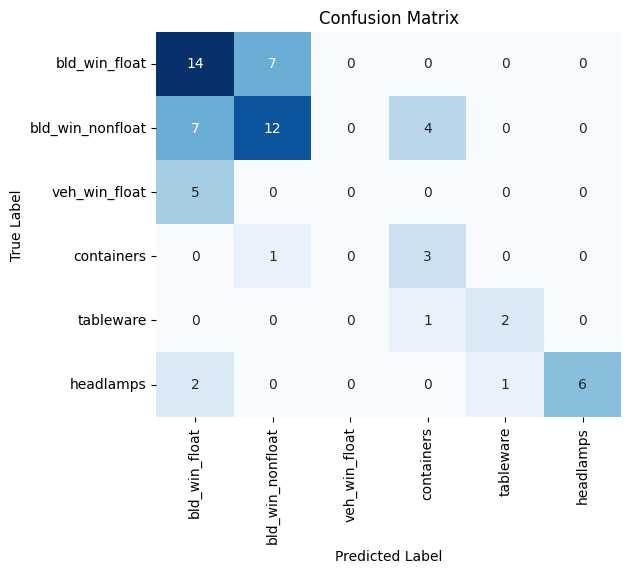

                  precision    recall  f1-score   support

   bld_win_float       0.50      0.67      0.57        21
bld_win_nonfloat       0.60      0.52      0.56        23
   veh_win_float       0.00      0.00      0.00         5
      containers       0.38      0.75      0.50         4
       tableware       0.67      0.67      0.67         3
       headlamps       1.00      0.67      0.80         9

        accuracy                           0.57        65
       macro avg       0.52      0.55      0.52        65
    weighted avg       0.57      0.57      0.55        65



In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_hat = knn.predict(X_test)
plot_cm(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat, target_names=classes, zero_division=0))

## Decision Tree

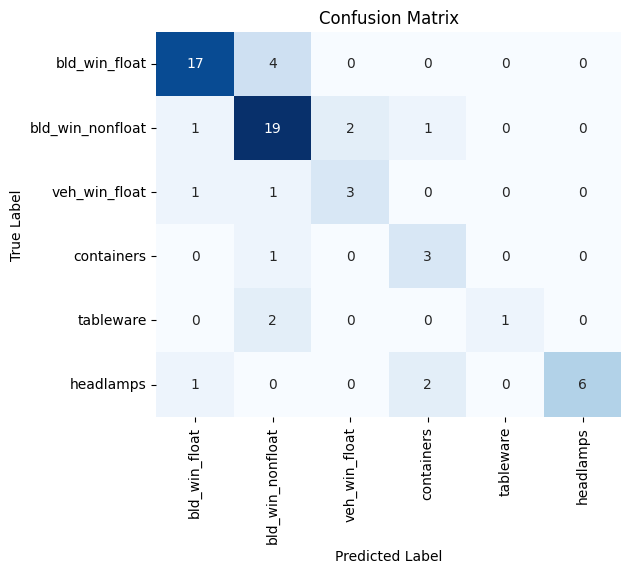

                  precision    recall  f1-score   support

   bld_win_float       0.85      0.81      0.83        21
bld_win_nonfloat       0.70      0.83      0.76        23
   veh_win_float       0.60      0.60      0.60         5
      containers       0.50      0.75      0.60         4
       tableware       1.00      0.33      0.50         3
       headlamps       1.00      0.67      0.80         9

        accuracy                           0.75        65
       macro avg       0.78      0.66      0.68        65
    weighted avg       0.79      0.75      0.75        65



In [ ]:
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)
y_hat = dt_clf.predict(X_test)
plot_cm(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat, target_names=classes, zero_division=0))

## Random Fores

C:\Users\mikja\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


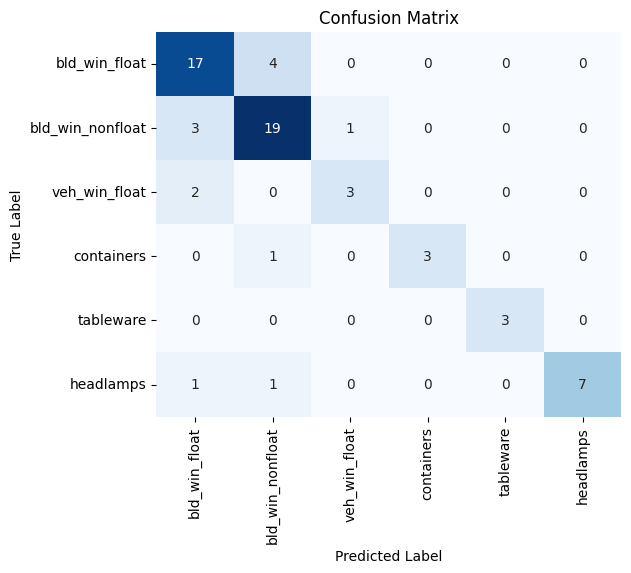

                  precision    recall  f1-score   support

   bld_win_float       0.74      0.81      0.77        21
bld_win_nonfloat       0.76      0.83      0.79        23
   veh_win_float       0.75      0.60      0.67         5
      containers       1.00      0.75      0.86         4
       tableware       1.00      1.00      1.00         3
       headlamps       1.00      0.78      0.88         9

        accuracy                           0.80        65
       macro avg       0.87      0.79      0.83        65
    weighted avg       0.81      0.80      0.80        65



In [ ]:
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)
y_hat = rf_clf.predict(X_test)
plot_cm(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat, target_names=classes, zero_division=0))

## AdaBoost

C:\Users\mikja\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


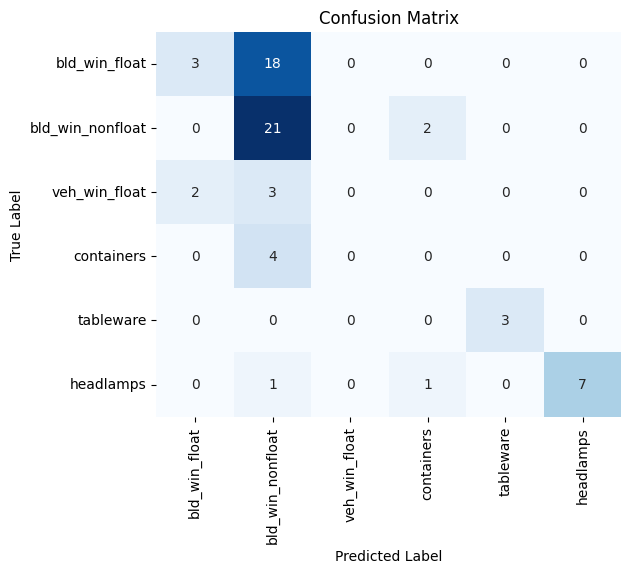

                  precision    recall  f1-score   support

   bld_win_float       0.60      0.14      0.23        21
bld_win_nonfloat       0.45      0.91      0.60        23
   veh_win_float       0.00      0.00      0.00         5
      containers       0.00      0.00      0.00         4
       tableware       1.00      1.00      1.00         3
       headlamps       1.00      0.78      0.88         9

        accuracy                           0.52        65
       macro avg       0.51      0.47      0.45        65
    weighted avg       0.54      0.52      0.45        65



In [ ]:
ada_clf = AdaBoostClassifier()
ada_clf.fit(X_train, y_train)
y_hat = ada_clf.predict(X_test)
plot_cm(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat, target_names=classes, zero_division=0))

## XGBoost

In [ ]:
y_train = y_train - 1
y_test = y_test - 1
y_train = np.where(y_train > 2, y_train - 1, y_train)
y_test = np.where(y_test > 2, y_test - 1, y_test)

In [ ]:
np.unique(y_test)

array([0, 1, 2, 3, 4, 5])

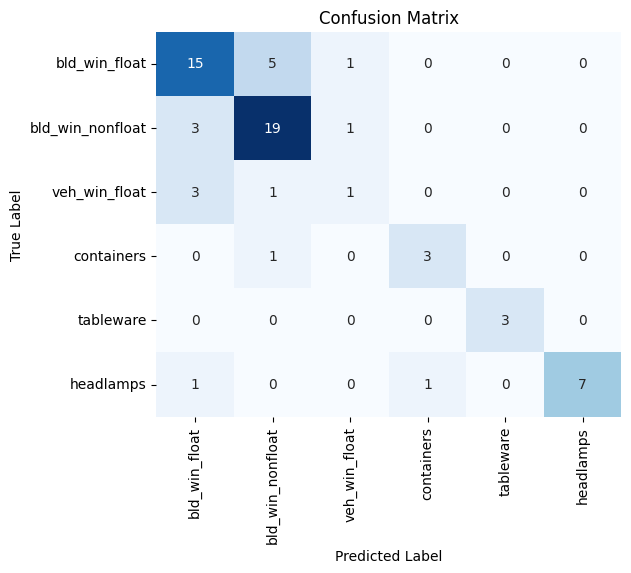

                  precision    recall  f1-score   support

   bld_win_float       0.68      0.71      0.70        21
bld_win_nonfloat       0.73      0.83      0.78        23
   veh_win_float       0.33      0.20      0.25         5
      containers       0.75      0.75      0.75         4
       tableware       1.00      1.00      1.00         3
       headlamps       1.00      0.78      0.88         9

        accuracy                           0.74        65
       macro avg       0.75      0.71      0.72        65
    weighted avg       0.74      0.74      0.73        65



In [ ]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_hat = xgb.predict(X_test)
plot_cm(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat, target_names=classes, zero_division=0))

## Podsumowanie

| Klasyfikator  | Accuracy | Macro avg F1 | Weighted avg F1 | Uwagi |
|:---------------|:-----------|:---------------|:----------------|:-----------------------------|
| **KNN**           | 0.57      | 0.52          | 0.55             | Najniższy wynik, lecz najprostszy klasyfikator. Pominięta klasa `veh_win_float` |
| **Decision Tree** | 0.75      | 0.68          | 0.75             | Udało się nie pomijać zawsze ani jednej klasy |
| **Random Forest** | 0.80      | 0.83          | 0.80             | Najlepszy wynik; wysokie F1-score w niemal wszystkich klasach |
| **AdaBoost**      | 0.52      | 0.45          | 0.45             | Bardzo nierównomierny - kompletnie pominął często występującą klasę `bld_win_float`        i uznawał ją za klasę `bld_win_nonfloat` |
| **XGBoost**       | 0.74      | 0.72          | 0.73             | Stabilny, dobre wyniki zbliżone do Decision Tree |



# Zadanie 2 - Detektyw NYPD

## Przewidzieć lub zidentyfikować przypadki, w których CCRB Allegation Disposition ≠ Investigator Recommendatione?
Jest to wykrywanie anomalii / klasyfikacja niezgodności między detektywem a board of NYPD

In [75]:
df = pd.read_csv('civilian_complaint.csv')

df['target_disagreement'] = (df['CCRB Allegation Disposition'] != df['Investigator Recommendation']).astype(int)

X = df.drop(columns=['CCRB Allegation Disposition', 'Investigator Recommendation', 'target_disagreement'])
y = df['target_disagreement']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

## EDA

In [94]:
X_train[X_train['Complaint Id'] == 202000071]

,As Of Date,Complaint Id,Complaint Officer Number,Tax ID,Officer Rank Abbreviation At Incident,Officer Rank At Incident,Officer Command At Incident,Officer Days On Force At Incident,Allegation Record Identity,FADO Type,Allegation,Victim/Alleged Victim Age Range At Incident,Victim/Alleged Victim Gender,Victim / Alleged Victim Race (Legacy),Victim / Alleged Victim Race / Ethnicity,NYPD Allegation Disposition
36434,06/04/2025,202000071,2,962772.0,POF,Police Officer,MTN PCT,1178.0,1083686,Force,Physical force,09 < Age <= 14,Female/Woman,Hispanic,NaN,APU Not guilty
203132,06/04/2025,202000071,1,950110.0,POM,Police Officer,MTN PCT,3102.0,1083098,Force,Physical force,20 < Age <= 24,Male/Man,Hispanic,NaN,APU Not guilty
354171,06/04/2025,202000071,2,962772.0,POF,Police Officer,MTN PCT,1178.0,1108748,Abuse of Authority,Failed to Obtain Language Interpretation,09 < Age <= 14,Female/Woman,Hispanic,NaN,APU Not guilty
272344,06/04/2025,202000071,1,950110.0,POM,Police Officer,MTN PCT,3102.0,1088854,Force,Physical force,NaN,NaN,NaN,NaN,NaN
4965,06/04/2025,202000071,4,966302.0,POM,Police Officer,MTN PCT,549.0,1127303,Force,Physical force,09 < Age <= 14,Female/Woman,Hispanic,NaN,NaN
178850,06/04/2025,202000071,3,942902.0,SGT,Sergeant,MTN PCT,4740.0,1128835,Force,Physical force,20 < Age <= 24,Male/Man,Hispanic,NaN,NaN
359469,06/04/2025,202000071,1,950110.0,POM,Police Officer,MTN PCT,3102.0,1128828,Abuse of Authority,Threat of force (verbal or physical),20 < Age <= 24,Male/Man,Hispanic,NaN,APU Not guilty
214089,06/04/2025,202000071,5,904994.0,SGT,Sergeant,CW T TF,9621.0,1126667,Abuse of Authority,Refusal to provide name,59 < Age <= 64,Male/Man,White,NaN,NaN


z przykrością stwierdzam, że odpowiedni podział danych w tym dataset, odpowiednie przetworzenie danych oraz ogromna dysproporcja w klasach powodują, że zajęłoby to kilka dobrych godzin, aby móc przystąpić do EDA oraz modelowania, a nie na tym polega ta lsita, więc zdecydowałem się zabrać za inny dataset

# Zadanie 2 - Hospital Readmissions

In [16]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [17]:
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 

diabetes_130 = fetch_ucirepo(id=296)

C:\Users\mikja\AppData\Roaming\Python\Python312\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)
C:\Users\mikja\AppData\Roaming\Python\Python312\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [18]:
data = diabetes_130.data.original.copy()
data['readmitted'] = data['readmitted'].map({'NO': 0, '>30': 1, '<30': 2})

In [19]:
np.unique(data['readmitted'], return_counts=True)

(array([0, 1, 2]), array([54864, 35545, 11357]))

## Feature Engineering

source: https://github.com/lelandburrill/diabetes_readmission/blob/main/p00_data_processing.ipynb

In [20]:
data['expiration_ind'] = data['discharge_disposition_id'].isin([11,13,14,19,20,21]).astype('int')

data['MP_DM_payer_ind'] = ((data['payer_code'] == 'MP') | (data['payer_code'] == 'DM')).astype(int)

data['diag_1'] = data['diag_1'].astype(str).str[ :3]
data['diag_2'] = data['diag_2'].astype(str).str[ :3]
data['diag_3'] = data['diag_3'].astype(str).str[ :3]

data['diag_1'] = data['diag_1'].replace('?', 'ZZZ')
data['diag_2'] = data['diag_2'].replace('?', 'ZZZ')
data['diag_3'] = data['diag_3'].replace('?', 'ZZZ')

In [21]:
data['diag_1_428_ind'] = ( data['diag_1']=='428' ).astype(int) #CHF NOS
data['diag_1_491_ind'] = ( data['diag_1']=='491' ).astype(int) #SIMPLE CHR BRONCHITIS
data['diag_1_493_ind'] = ( data['diag_1']=='493' ).astype(int) #EXTRINSIC ASTHMA NOS

data['diag_2_403_ind'] = ( data['diag_2']=='403' ).astype(int) #MAL HY KID W CR KID I-IV
data['diag_2_707_ind'] = ( data['diag_2']=='707' ).astype(int) #DECUBITUS ULCER
data['diag_2_585_ind'] = ( data['diag_2']=='585' ).astype(int) #CHRONIC RENAL FAILURE
data['diag_2_491_ind'] = ( data['diag_2']=='491' ).astype(int) #SIMPLE CHR BRONCHITIS

data['diag_3_403_ind'] = ( data['diag_3']=='403' ).astype(int) #MAL HY KID W CR KID I-IV
data['diag_3_585_ind'] = ( data['diag_3']=='585' ).astype(int) #CHRONIC RENAL FAILURE
data['diag_3_707_ind'] = ( data['diag_3']=='707' ).astype(int) #DECUBITUS ULCER

In [22]:
data['diag_1_driver_ind'] = data['diag_1'].isin([ '403' #MAL HY KID W CR KID I-IV
, '787' #NAUSEA WITH VOMITING
, '404' #MAL HY HT/KD I-IV W/O HF
, '707' #DECUBITUS ULCER
, '572' #ABSCESS OF LIVER
, '730' #AC OSTEOMYELITIS-UNSPEC
, 'V58' #RADIOTHERAPY ENCOUNTER
, '537' #ACQ PYLORIC STENOSIS
, '443' #RAYNAUD'S SYNDROME
, '292' #DRUG WITHDRAWAL
, '496' #CHR AIRWAY OBSTRUCT NEC
, '585' #CHRONIC RENAL FAILURE
, '282' #HEREDITARY SPHEROCYTOSIS
, '799' #ASPHYXIA
, '284' #CONGEN APLASTIC ANEMIA
, '567' #PERITONITIS IN INFEC DIS
, '293' #DELIRIUM D/T OTHER COND
, '924' #CONTUSION OF THIGH
, '340' #MULTIPLE SCLEROSIS
, '514' #PULM CONGEST/HYPOSTASIS
, '485' #BRONCHOPNEUMONIA ORG NOS
, '714' #RHEUMATOID ARTHRITIS
, '277' #CYSTIC FIBROS W/O ILEUS
, '150' #MAL NEO CERVICAL ESOPHAG
, '135' #SARCOIDOSIS
, '522']).astype(int) #PULPITIS

In [23]:
data['diag_2_driver_ind'] = data['diag_2'].isin([ '571' #ALCOHOLIC FATTY LIVER
, '404' #MAL HY HT/KD I-IV W/O HF
, '536' #ACHLORHYDRIA
, '202' #NDLR LYM UNSP XTRNDL ORG
, '396' #MITRAL/AORTIC STENOSIS
, '304' #OPIOID DEPENDENCE-UNSPEC
, '444' #ABD AORTIC EMBOLISM
, '581' #NEPHROTIC SYN, PROLIFER
, '731' #OSTEITIS DEFORMANS NOS
, 'E94' #ADV EFF ANALEPTICS
, '397' #TRICUSPID VALVE DISEASE
, '595' #ACUTE CYSTITIS
, '205' #AC MYL LEUK WO ACHV RMSN
, '490' #BRONCHITIS NOS
, '459' #HEMORRHAGE NOS
, '189' #MALIG NEOPL KIDNEY
, '154' #MAL NEO RECTOSIGMOID JCT
, '332' #PARALYSIS AGITANS
, 'V49' #DEFICIENCIES OF LIMBS
, '681' #CELLULITIS, FINGER NOS
, '150' #MAL NEO CERVICAL ESOPHAG
, '537' #ACQ PYLORIC STENOSIS
, '094' ]).astype(int) #TABES DORSALIS

In [24]:
data['diag_3_driver_ind'] = data['diag_3'].isin([  '682' #CELLULITIS OF FACE
, '070' #HEPATITIS A WITH COMA
, '536' #ACHLORHYDRIA
, 'V42' #KIDNEY TRANSPLANT STATUS
, '443' #RAYNAUD'S SYNDROME
, '304' #OPIOID DEPENDENCE-UNSPEC
, '284' #CONGEN APLASTIC ANEMIA
, '466' #ACUTE BRONCHITIS
, '459' #HEMORRHAGE NOS
, '581' #NEPHROTIC SYN, PROLIFER
, '337' #IDIOPATH AUTO NEUROPATHY
, '583' #PROLIFERAT NEPHRITIS NOS
, '203' #MULT MYE W/O ACHV RMSON
, 'V46' #DEPENDENCE ON ASPIRATOR
, '482' #K. PNEUMONIAE PNEUMONIA
, 'V49' #DEFICIENCIES OF LIMBS
, '444' #ABD AORTIC EMBOLISM
, '174' #MALIG NEO NIPPLE
, '456' #ESOPHAG VARICES W BLEED
, '519' #TRACHEOSTOMY COMP NOS
, 'E92' #ACC-POWERED LAWN MOWER
, 'V62' #UNEMPLOYMENT
, '356' #HERED PERIPH NEUROPATHY
, '711' #PYOGEN ARTHRITIS-UNSPEC
, '053' ]).astype(int)  #HERPES ZOSTER MENINGITIS

In [25]:
data.drop(columns=['weight', 'medical_specialty', 'expiration_ind'], inplace=True)

## Data split

In [26]:
X = data.drop(columns=['readmitted'])
y = data['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

train_df = pd.DataFrame(X_train, columns=X.columns)
test_df = pd.DataFrame(X_test, columns=X.columns)
train_df['readmitted'] = y_train.values
test_df['readmitted'] = y_test.values

## Post data split feature engineering

In [27]:
diag_1_freq_map = train_df['diag_1'].value_counts().to_dict()
diag_2_freq_map = train_df['diag_2'].value_counts().to_dict()
diag_3_freq_map = train_df['diag_3'].value_counts().to_dict()

train_df['diag_1_freq'] = train_df['diag_1'].map(diag_1_freq_map)
test_df['diag_1_freq'] = test_df['diag_1'].map(diag_1_freq_map)

train_df['diag_2_freq'] = train_df['diag_2'].map(diag_2_freq_map)
test_df['diag_2_freq'] = test_df['diag_2'].map(diag_2_freq_map)

train_df['diag_3_freq'] = train_df['diag_3'].map(diag_3_freq_map)
test_df['diag_3_freq'] = test_df['diag_3'].map(diag_3_freq_map)

test_df['diag_1_freq'] = test_df['diag_1_freq'].fillna(0)
test_df['diag_2_freq'] = test_df['diag_2_freq'].fillna(0)
test_df['diag_3_freq'] = test_df['diag_3_freq'].fillna(0)

## EDA

In [28]:
print(train_df.info())
print(train_df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
Index: 81412 entries, 100036 to 83774
Data columns (total 65 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              81412 non-null  int64 
 1   patient_nbr               81412 non-null  int64 
 2   race                      79596 non-null  object
 3   gender                    81412 non-null  object
 4   age                       81412 non-null  object
 5   admission_type_id         81412 non-null  int64 
 6   discharge_disposition_id  81412 non-null  int64 
 7   admission_source_id       81412 non-null  int64 
 8   time_in_hospital          81412 non-null  int64 
 9   payer_code                49206 non-null  object
 10  num_lab_procedures        81412 non-null  int64 
 11  num_procedures            81412 non-null  int64 
 12  num_medications           81412 non-null  int64 
 13  number_outpatient         81412 non-null  int64 
 14  number_emergency      

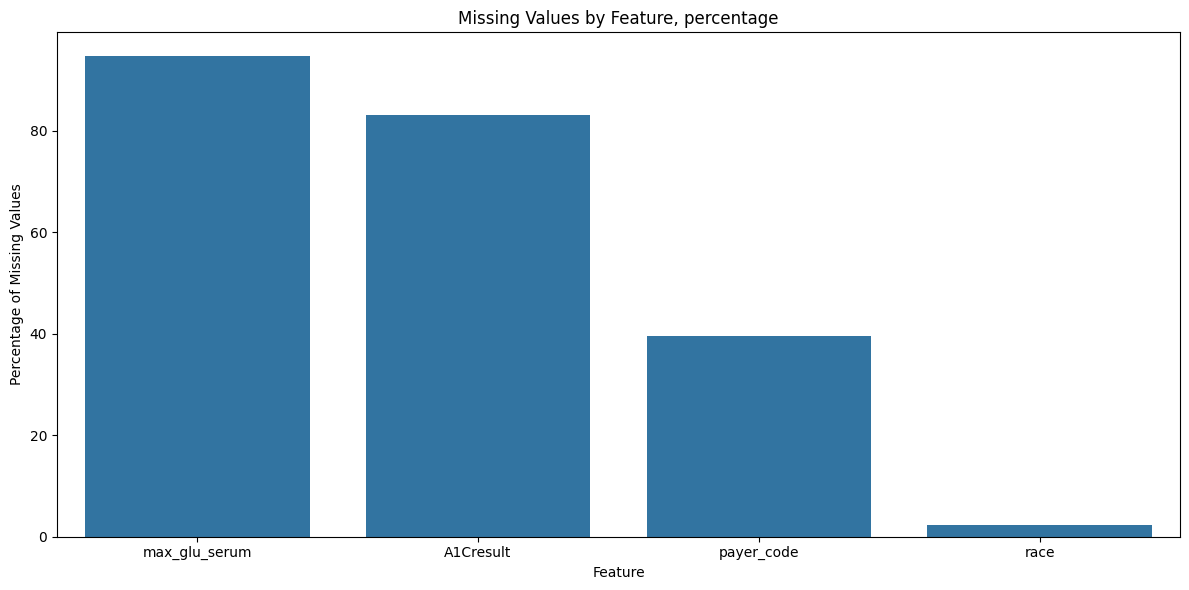

In [29]:
missing_percent = train_df.isnull().mean().sort_values(ascending=False) * 100
missing_percent = missing_percent[missing_percent > 0]

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percent.index, y= missing_percent.values)
plt.xlabel('Feature')
plt.ylabel('Percentage of Missing Values')
plt.title('Missing Values by Feature, percentage')
plt.tight_layout()
plt.show()


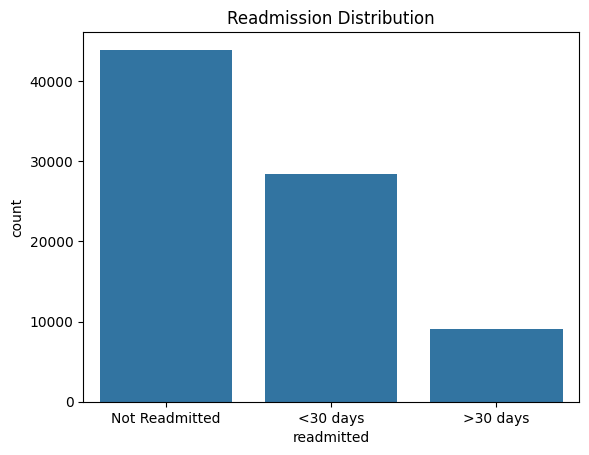

In [30]:
sns.countplot(x='readmitted', data=train_df)
plt.title('Readmission Distribution')
plt.xticks([0, 1, 2], ['Not Readmitted', '<30 days', '>30 days'])
plt.show()

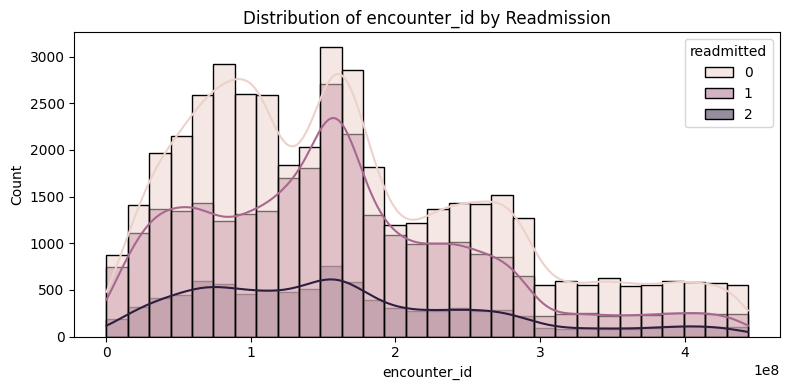

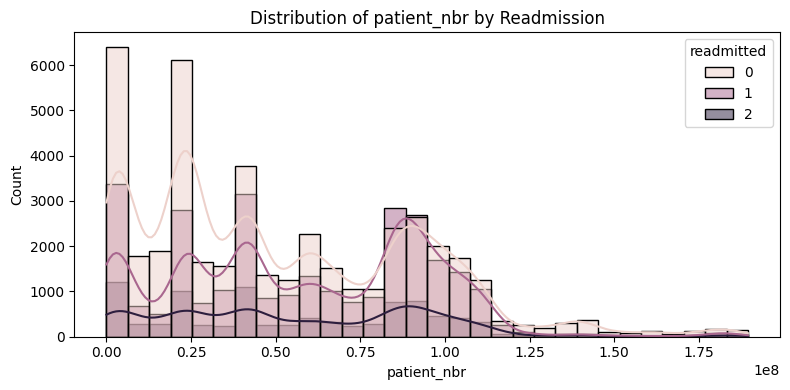

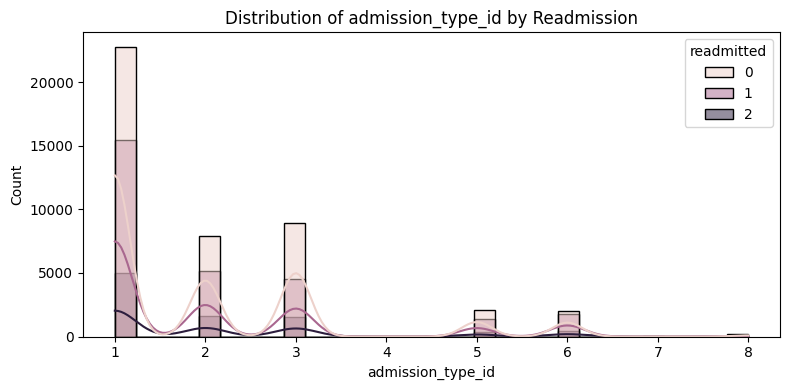

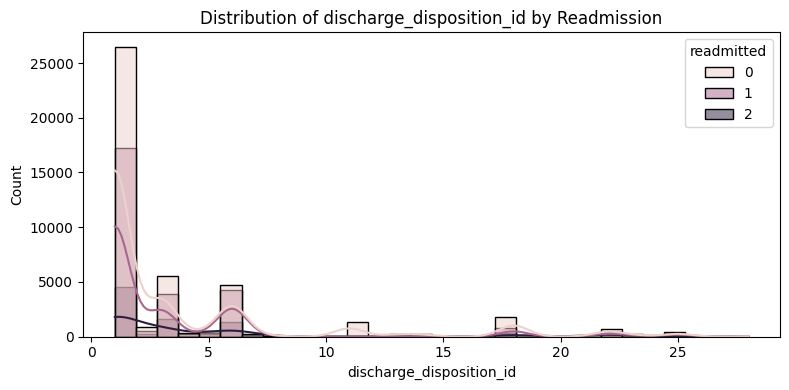

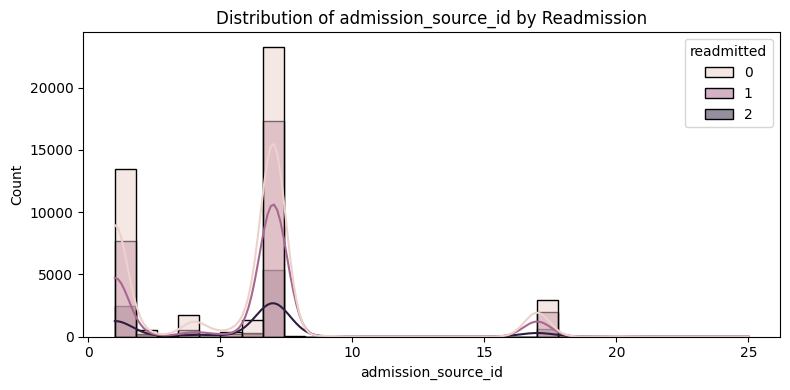

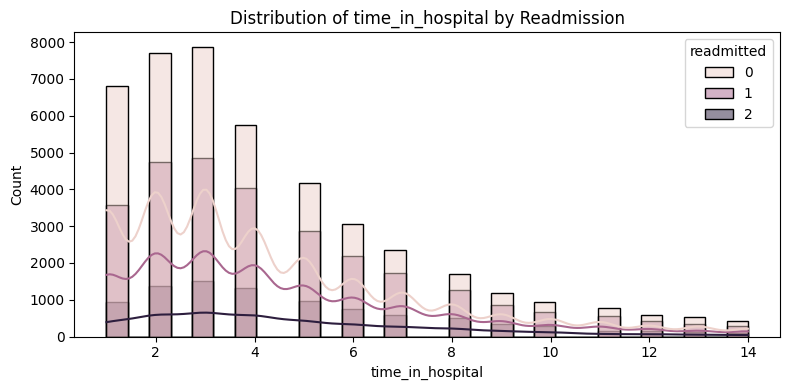

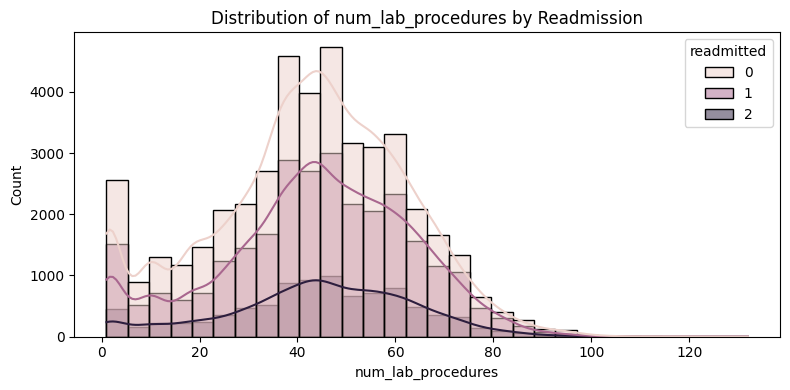

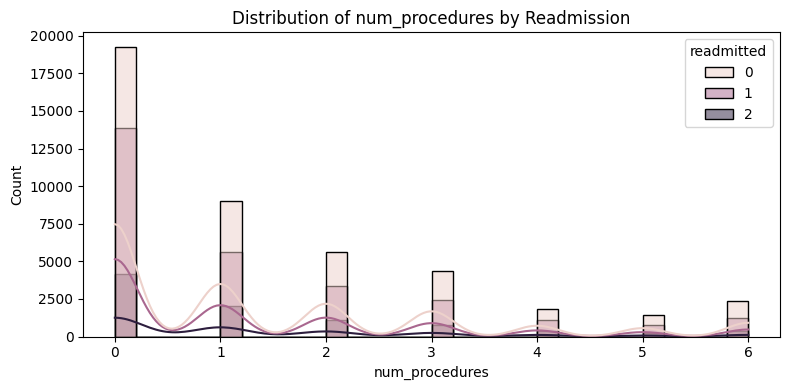

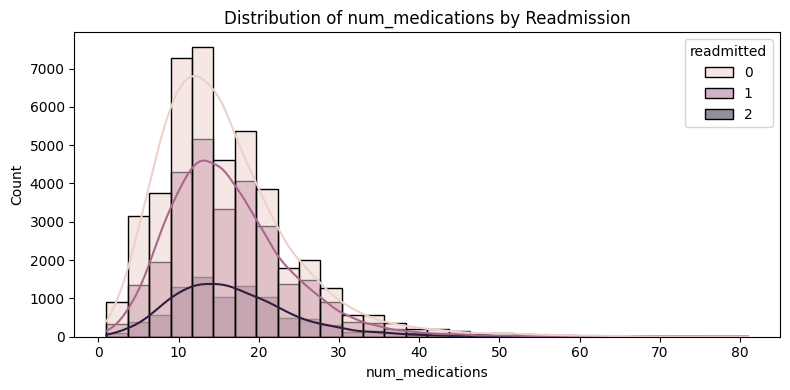

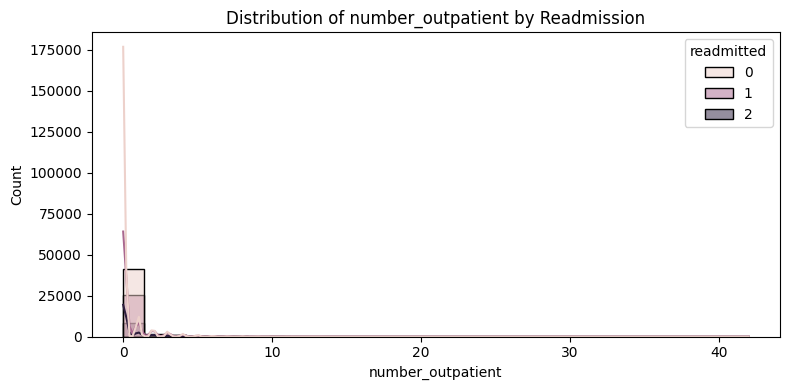

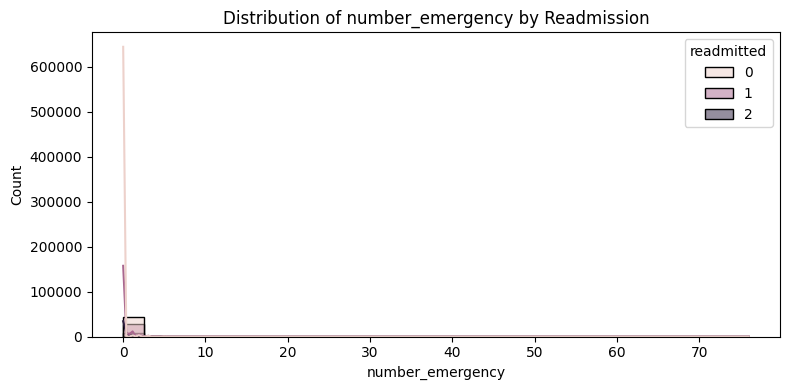

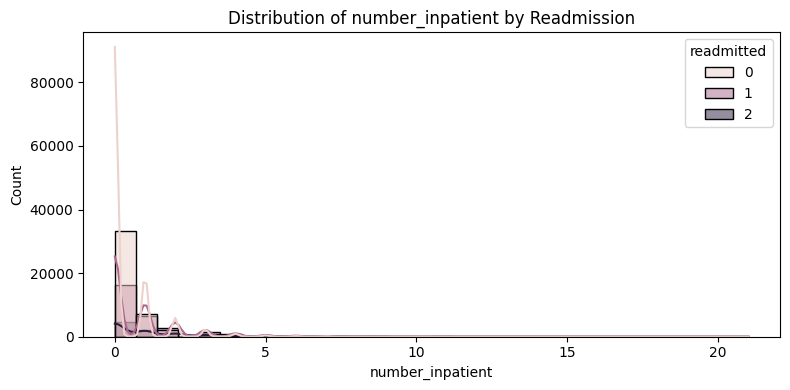

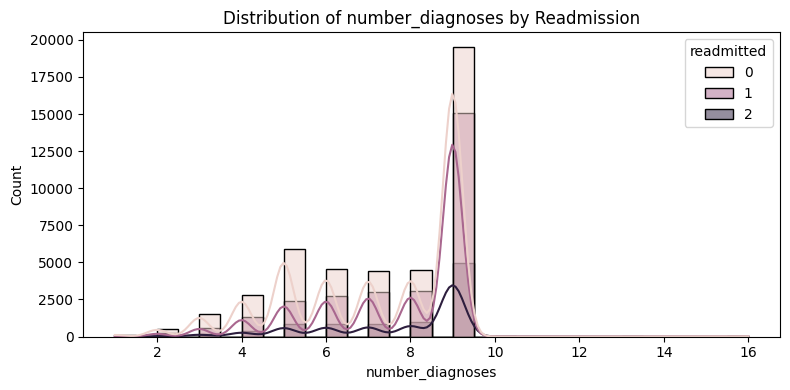

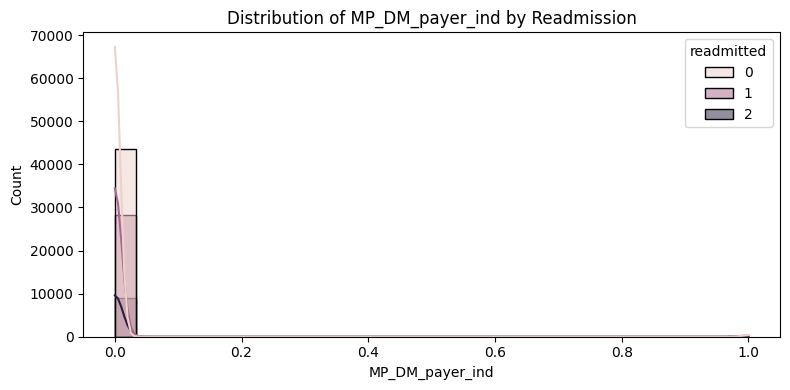

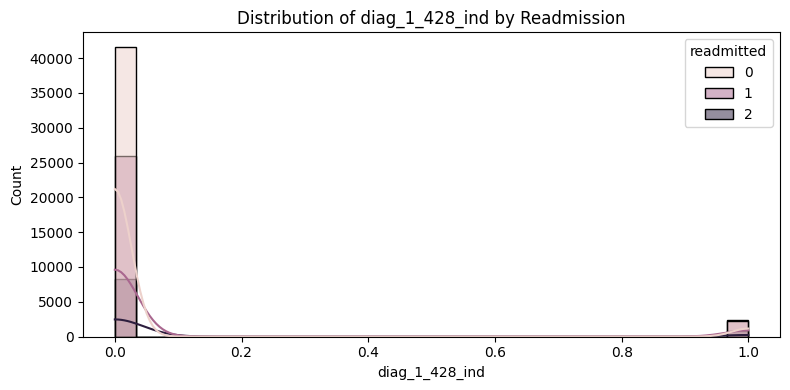

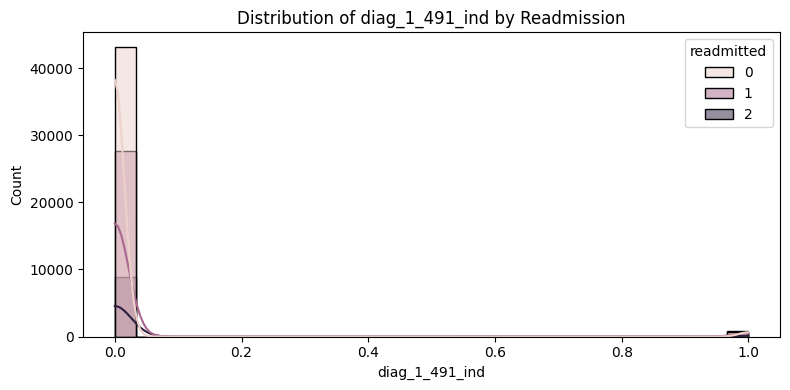

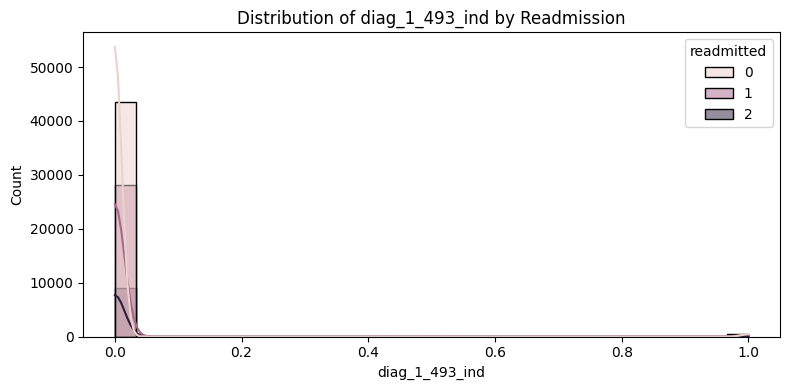

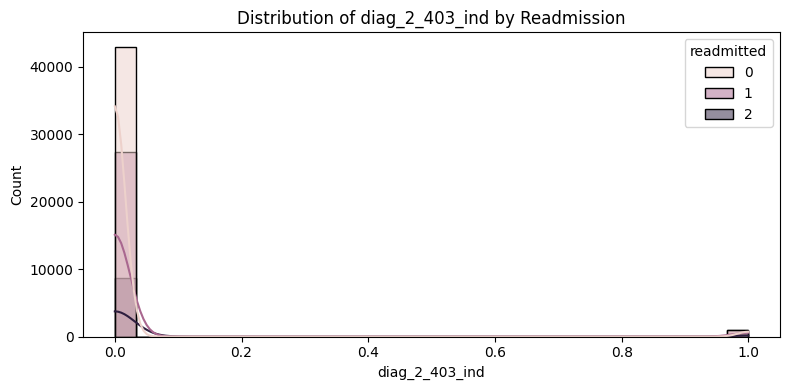

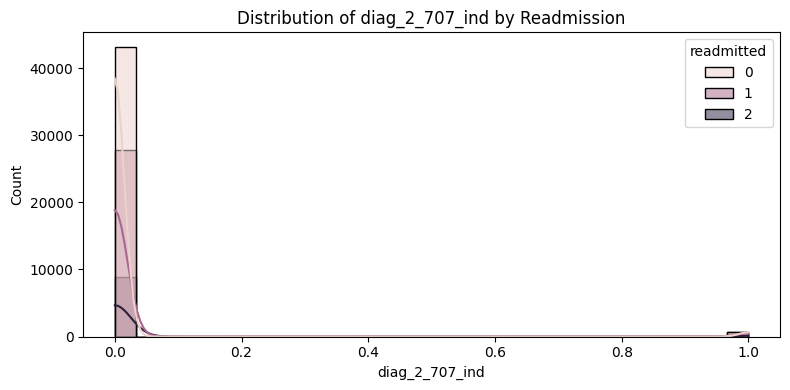

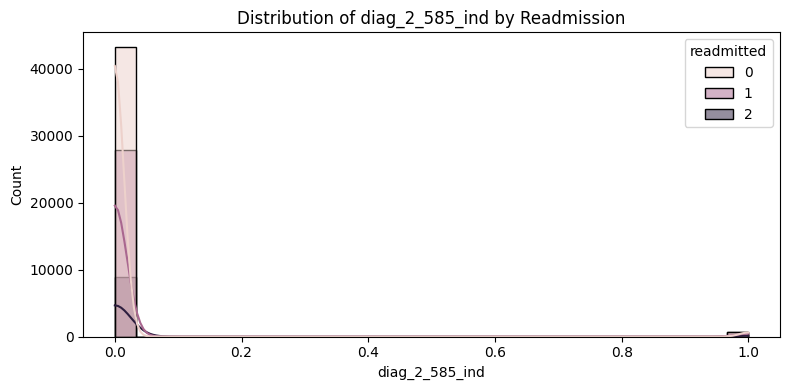

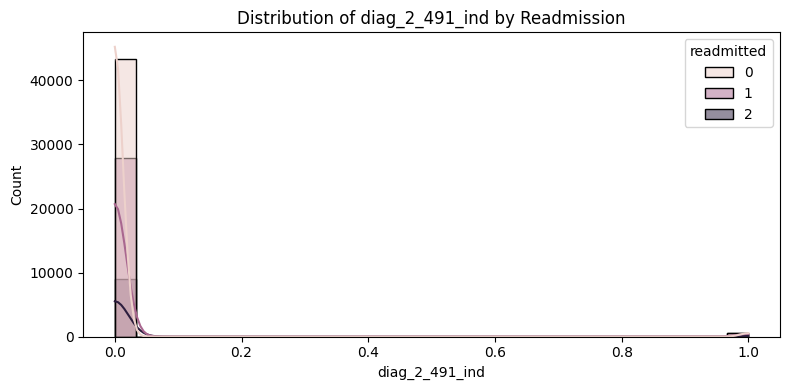

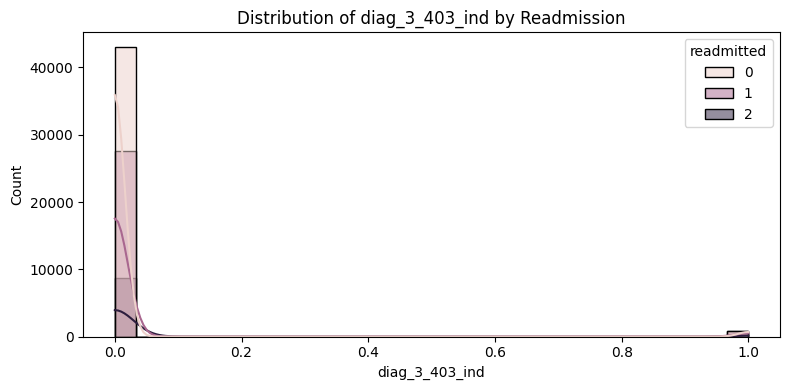

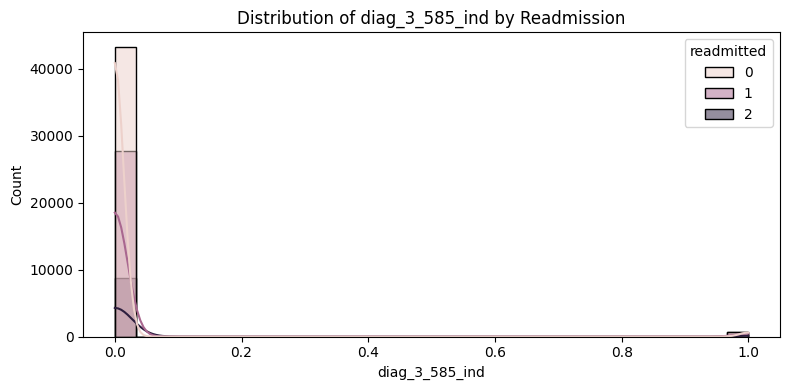

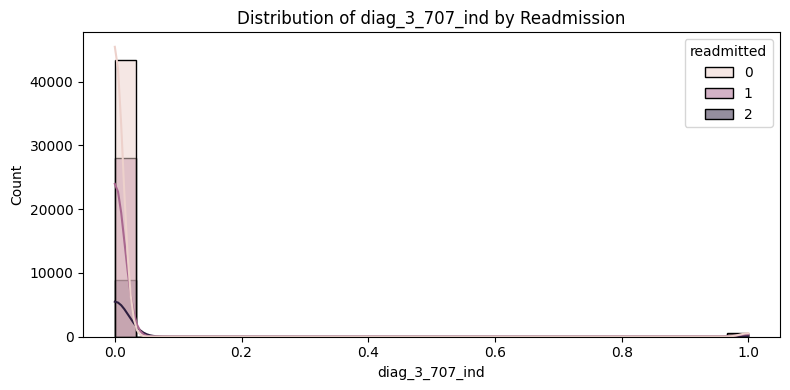

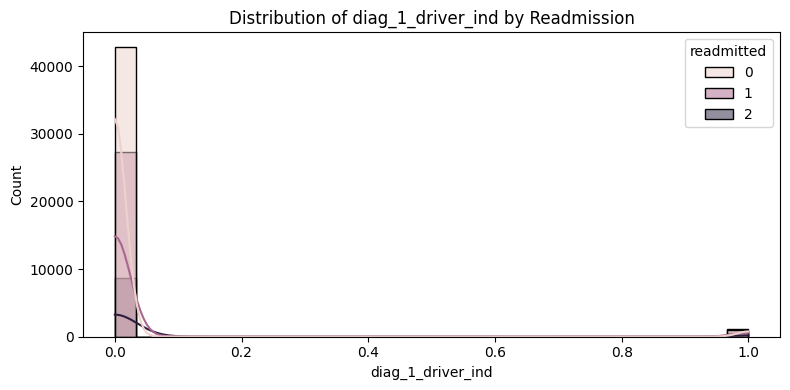

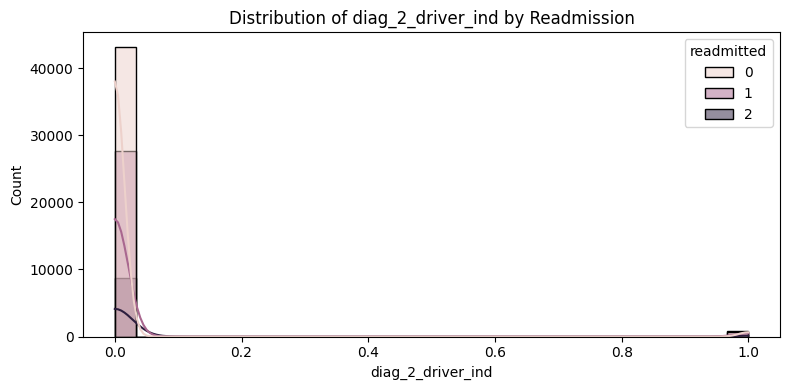

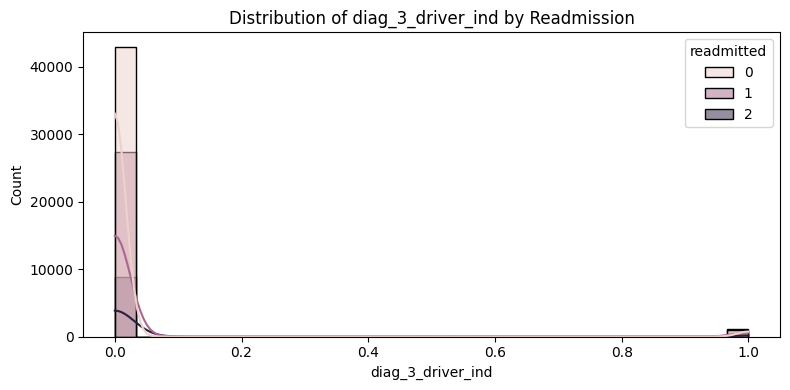

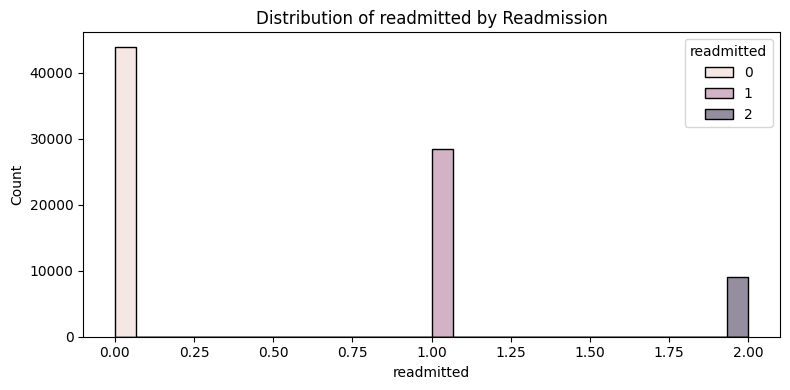

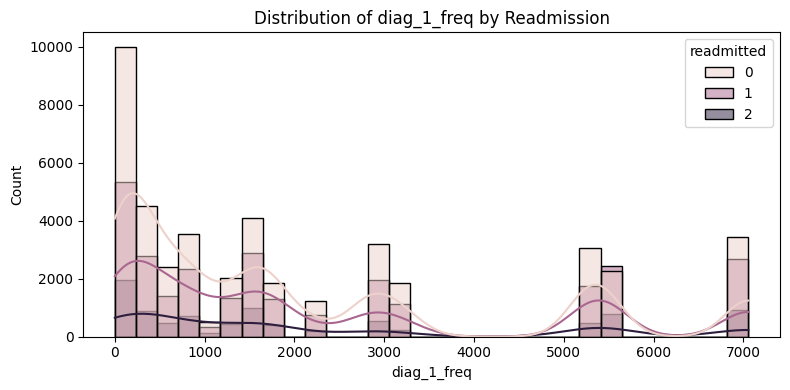

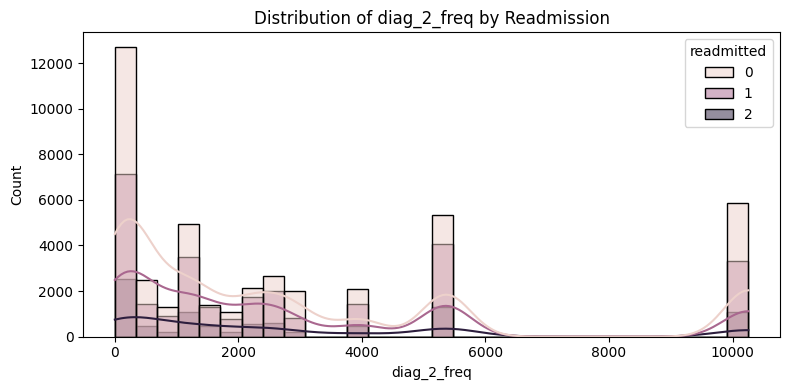

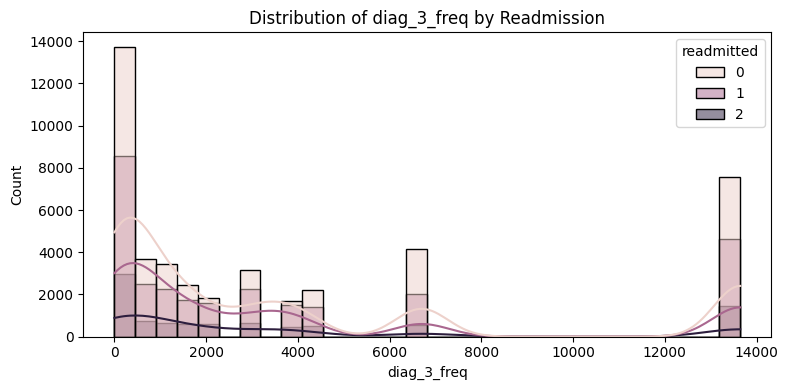

In [31]:
numeric_cols = train_df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=train_df, x=col, hue='readmitted', kde=True, bins=30)
    plt.title(f'Distribution of {col} by Readmission')
    plt.tight_layout()
    plt.show()

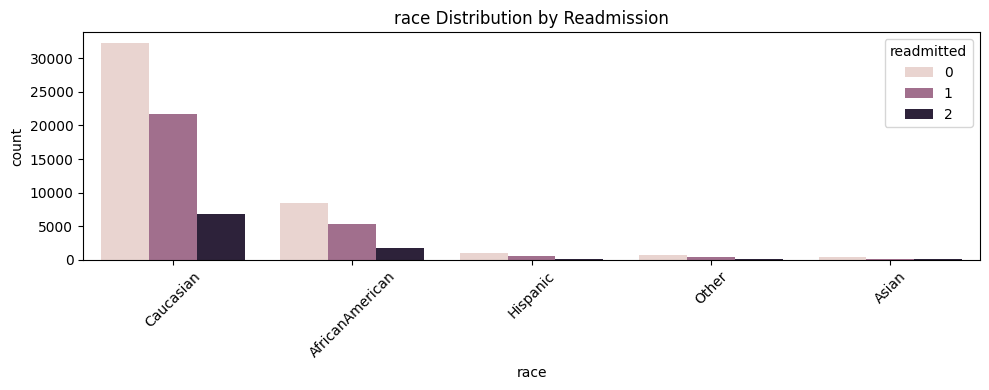

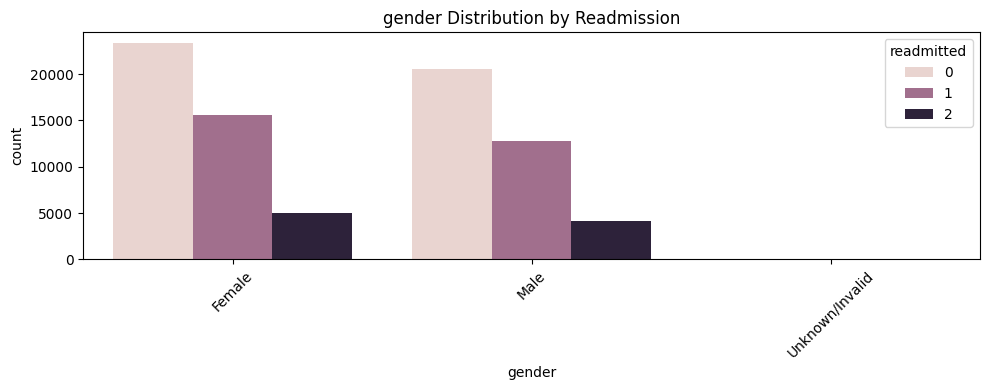

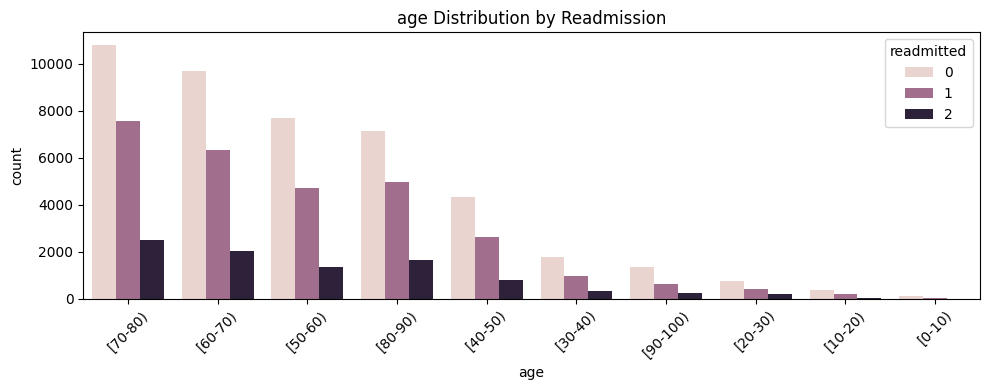

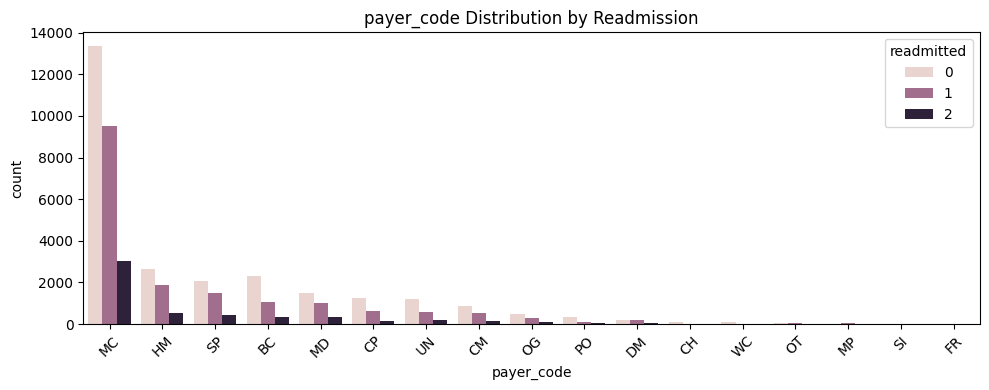

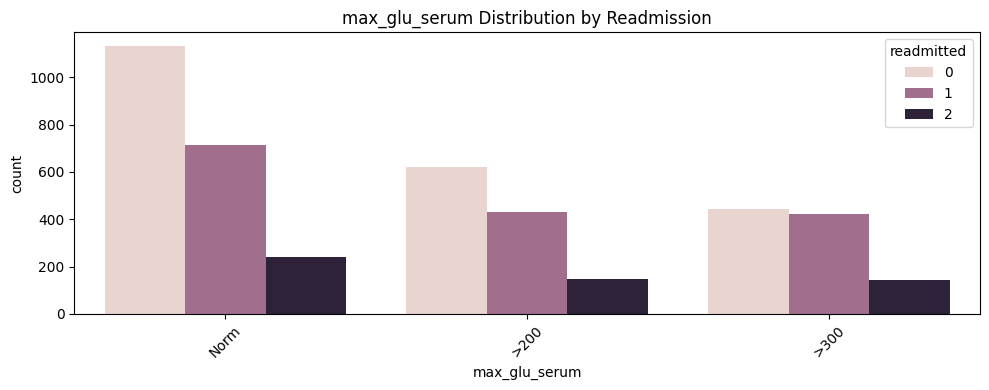

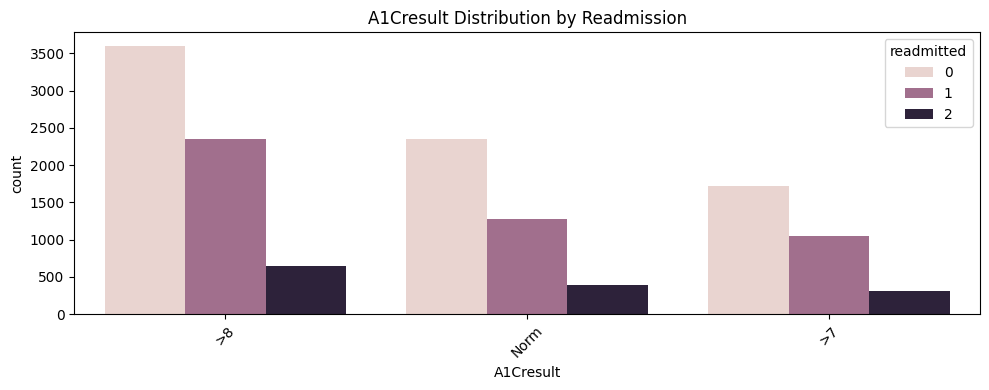

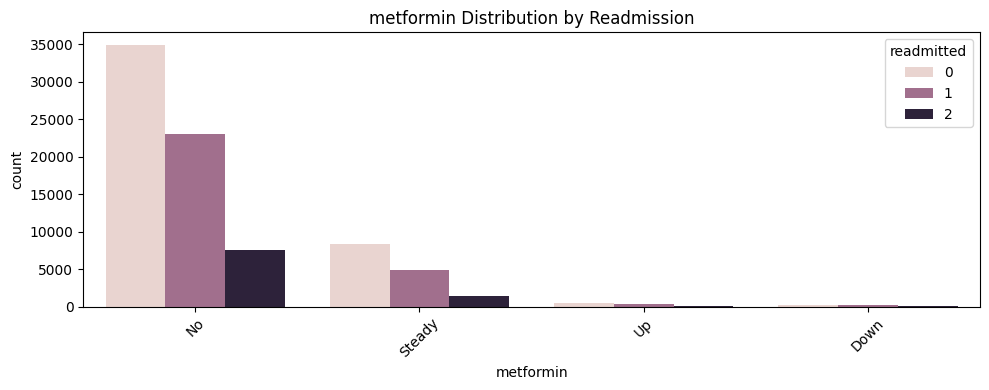

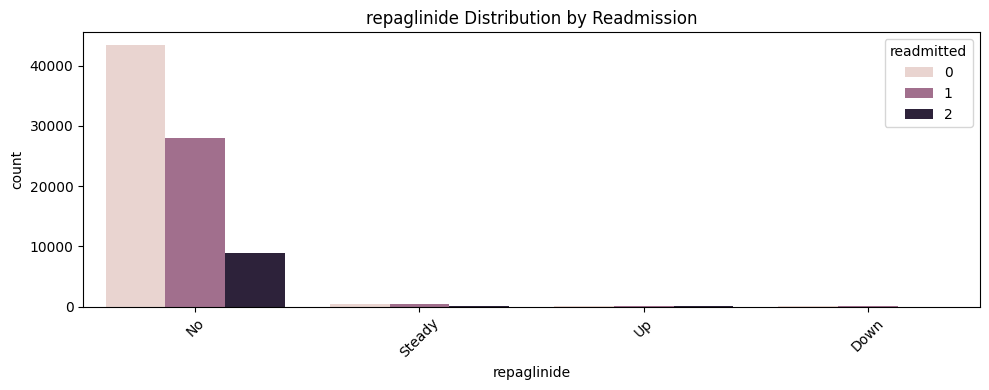

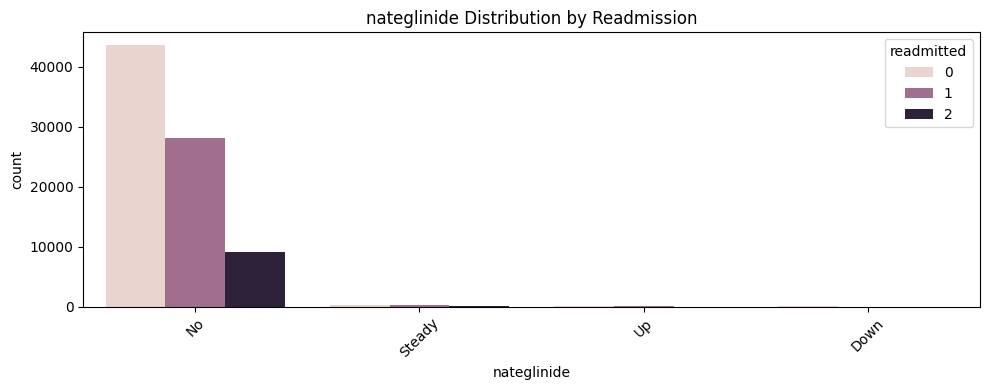

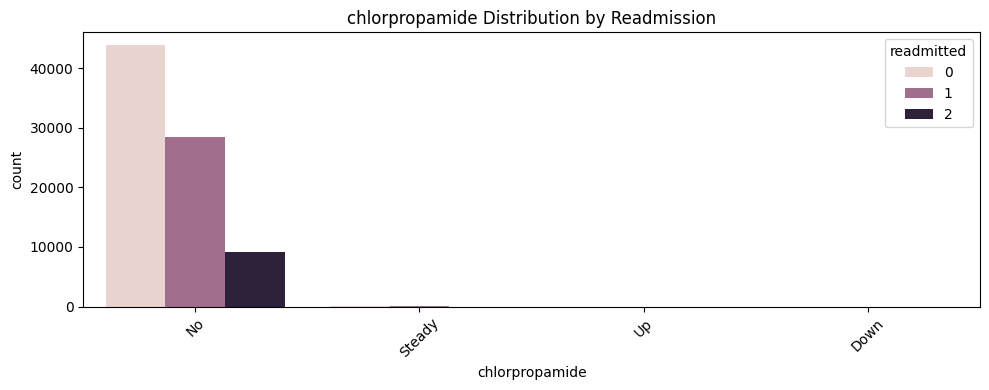

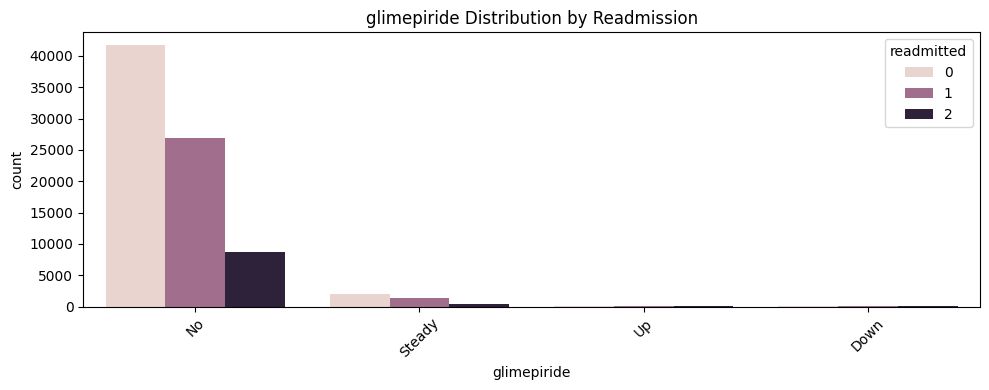

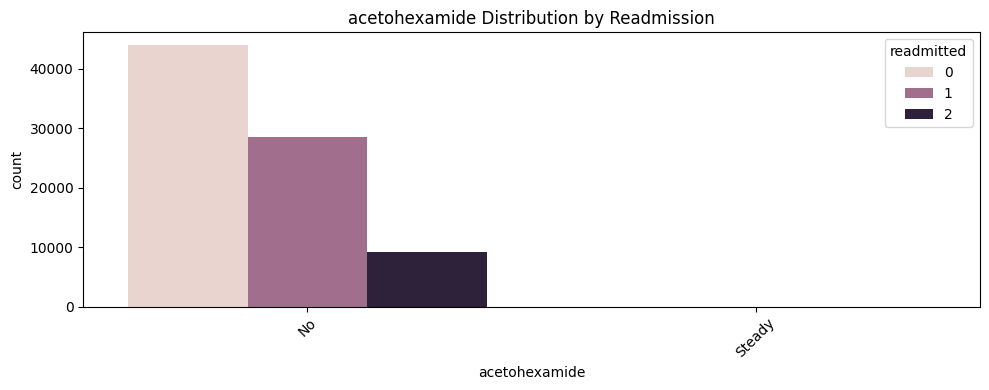

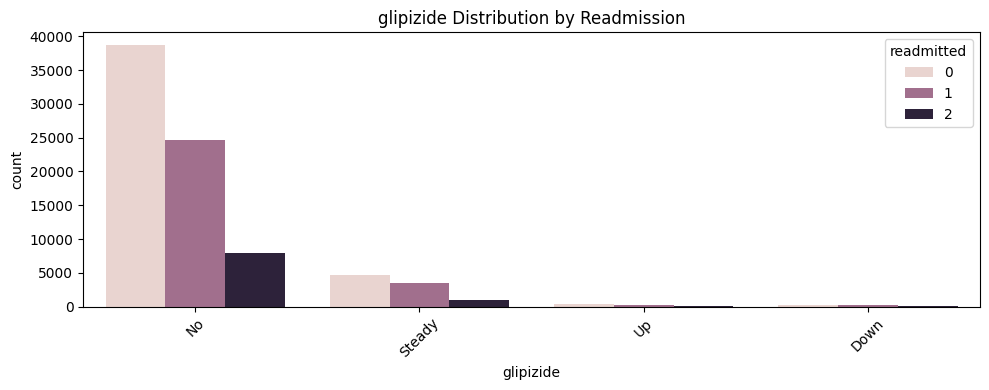

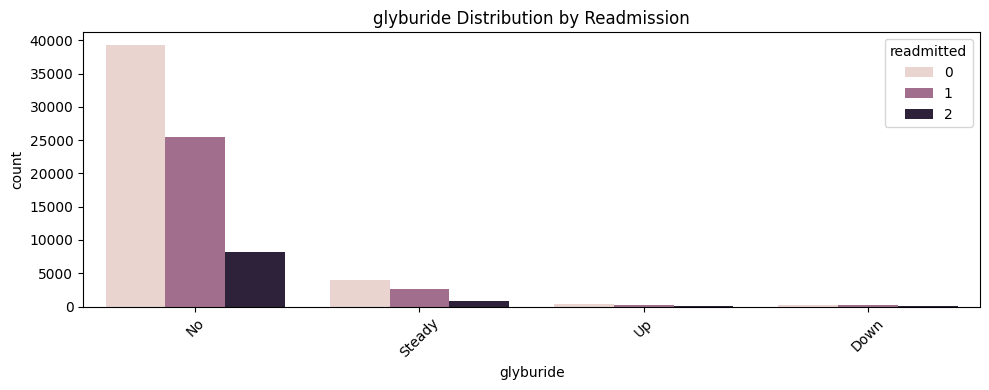

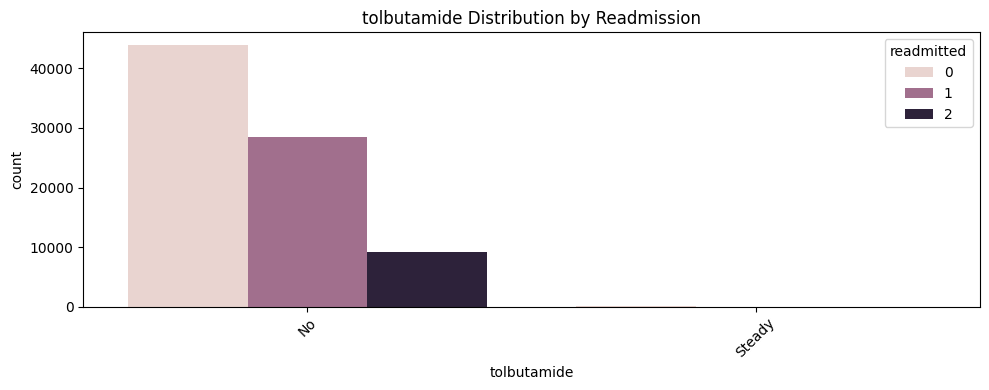

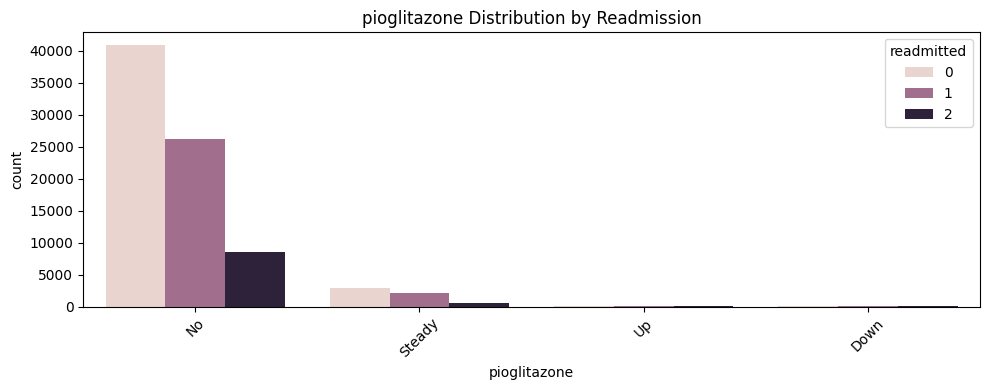

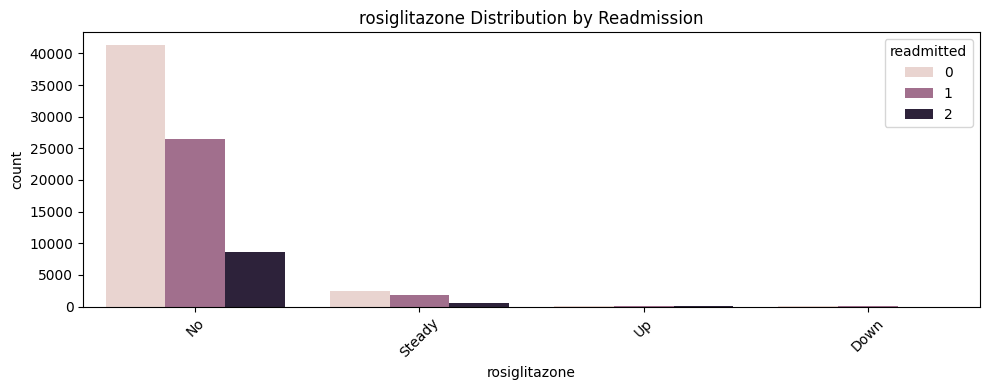

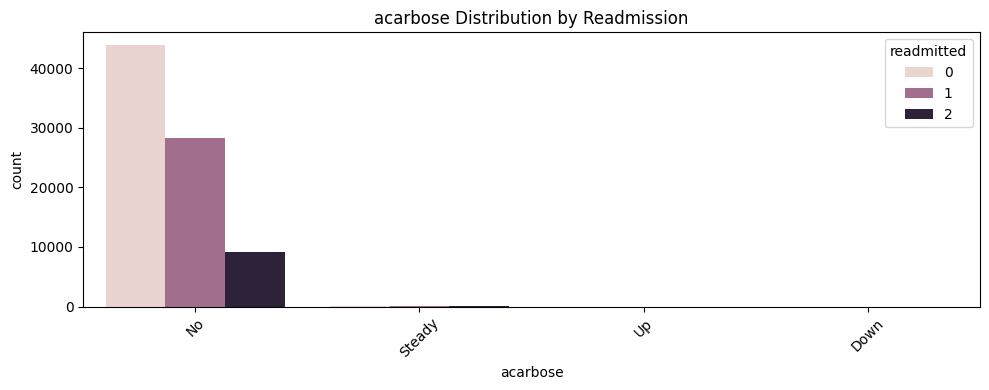

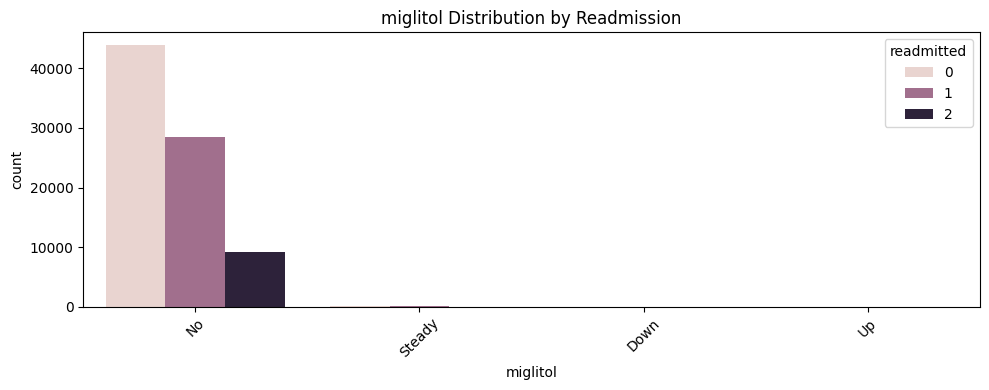

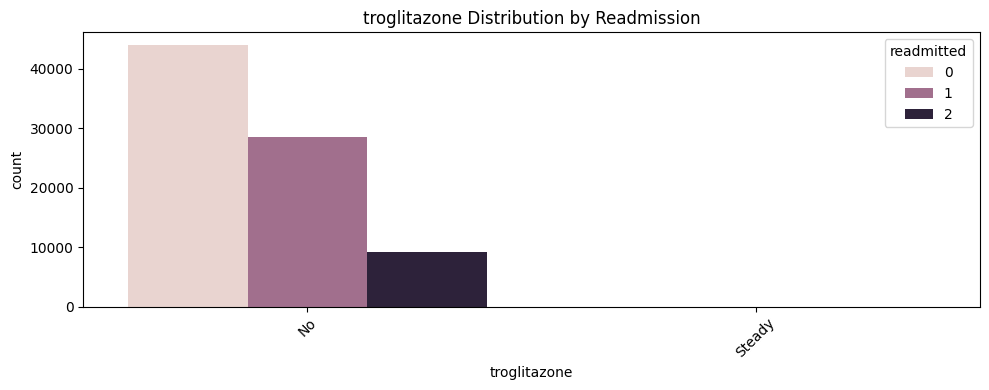

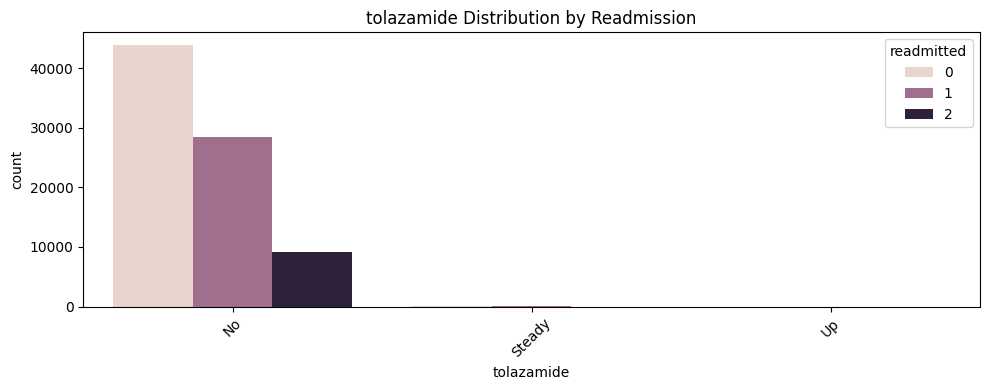

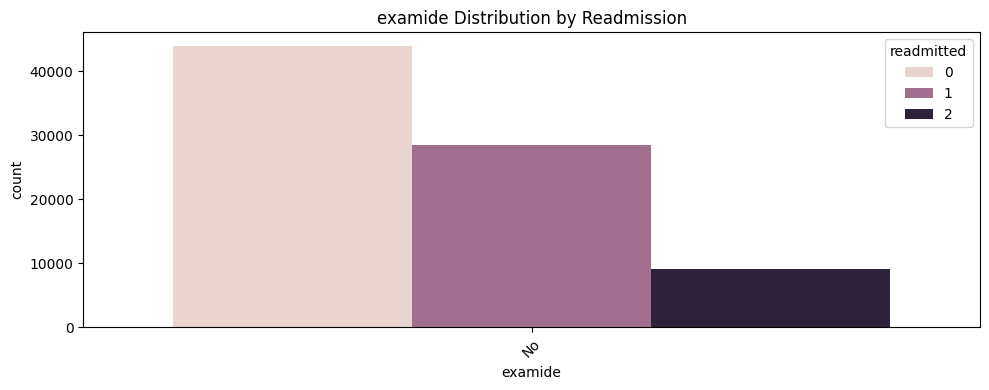

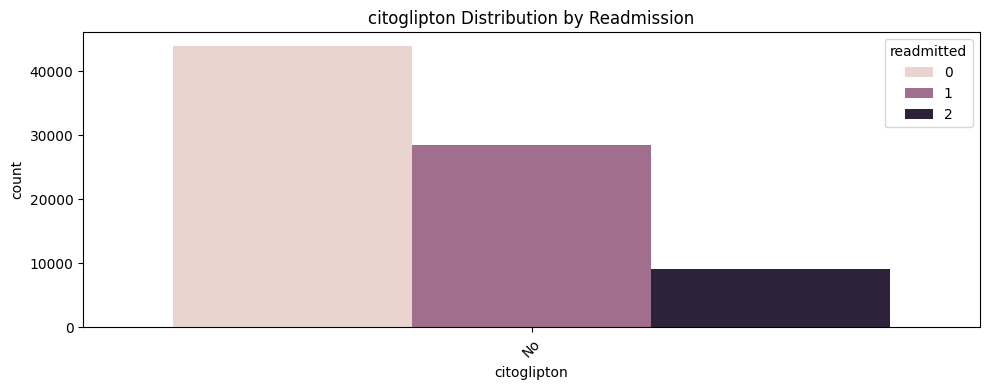

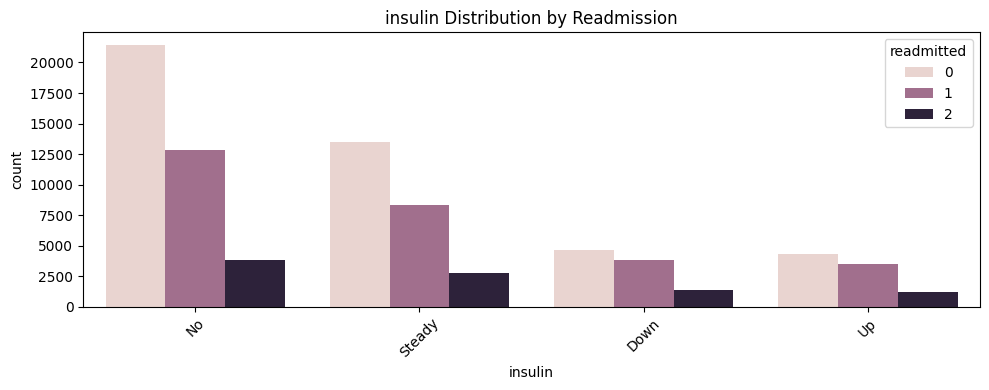

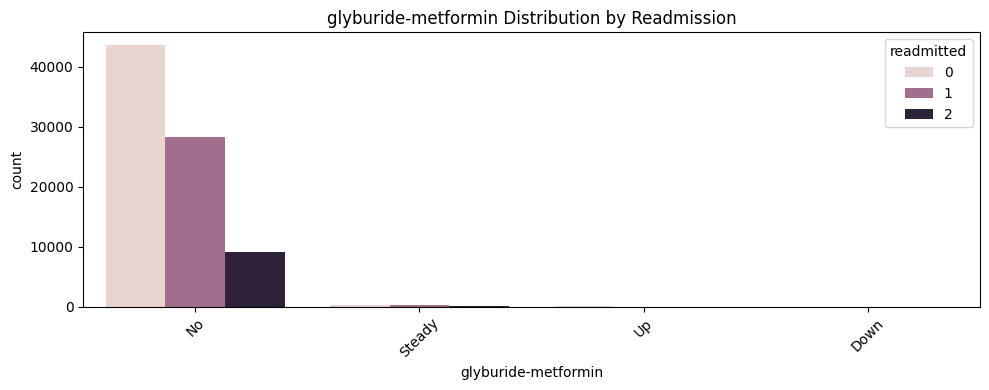

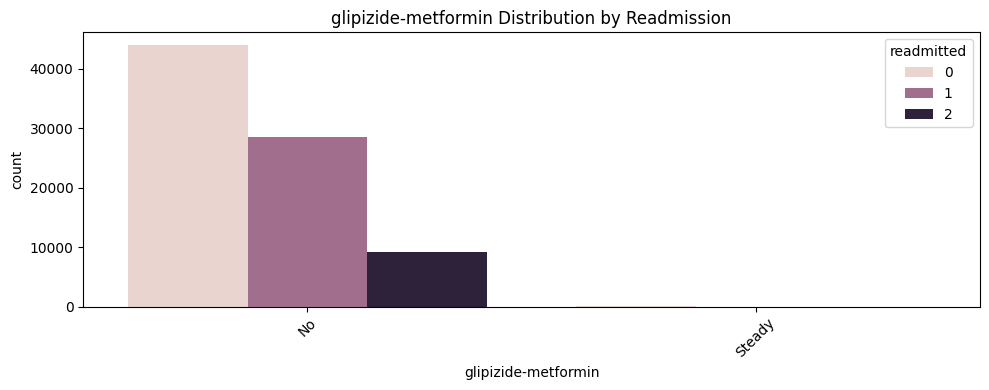

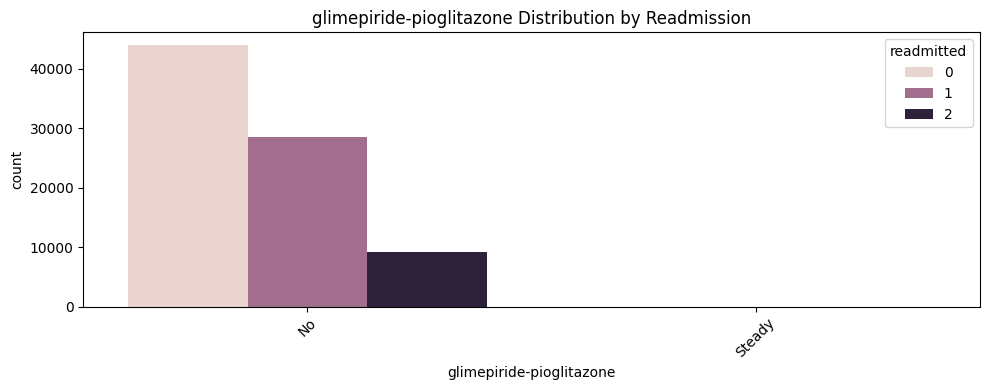

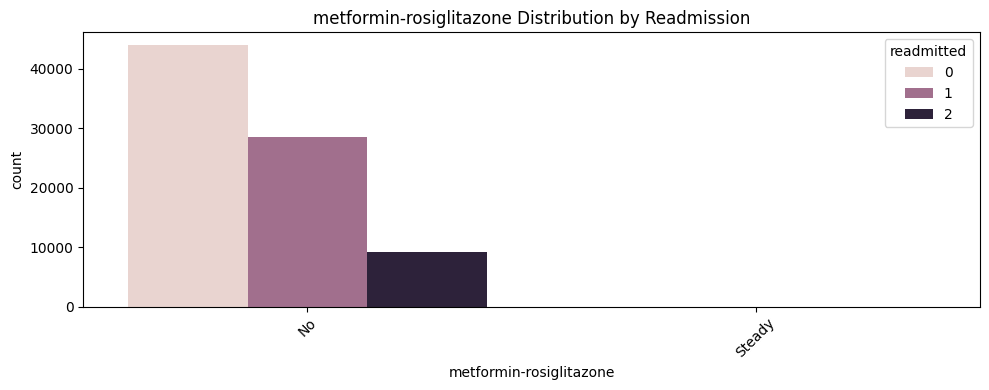

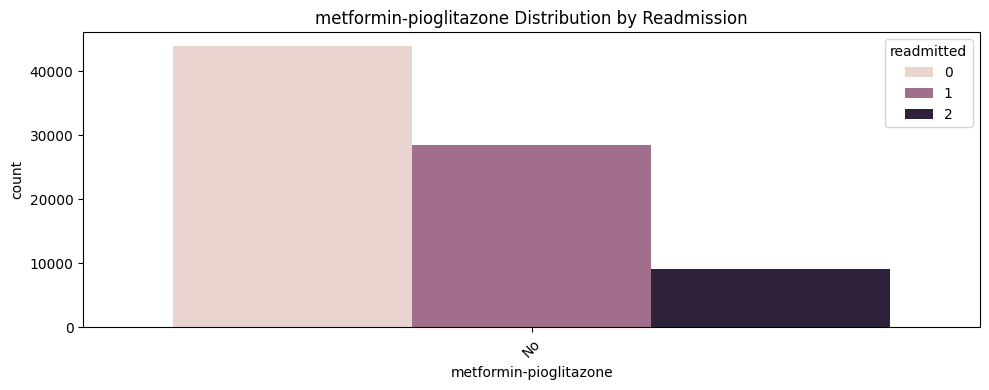

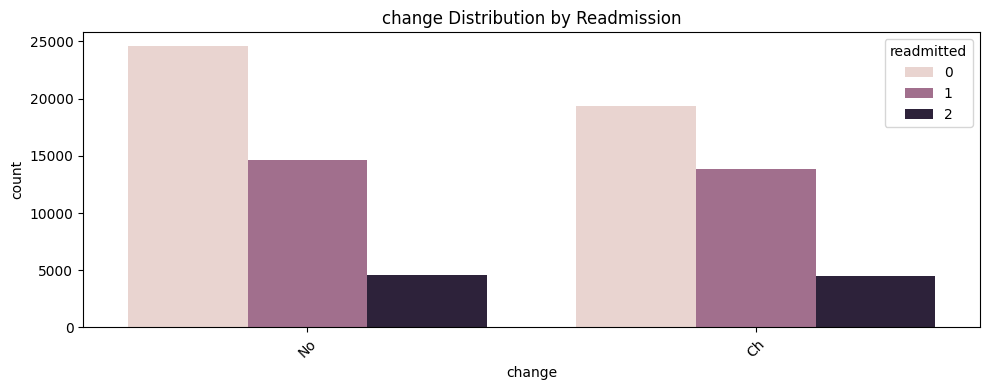

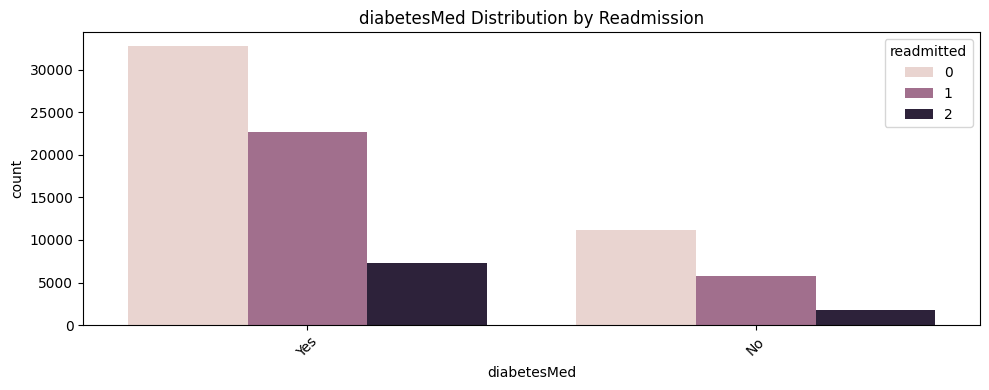

In [32]:
categorical_cols = train_df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    if train_df[col].nunique() < 20:
        plt.figure(figsize=(10, 4))
        sns.countplot(data=train_df, x=col, hue='readmitted', order=train_df[col].value_counts().index)
        plt.title(f'{col} Distribution by Readmission')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

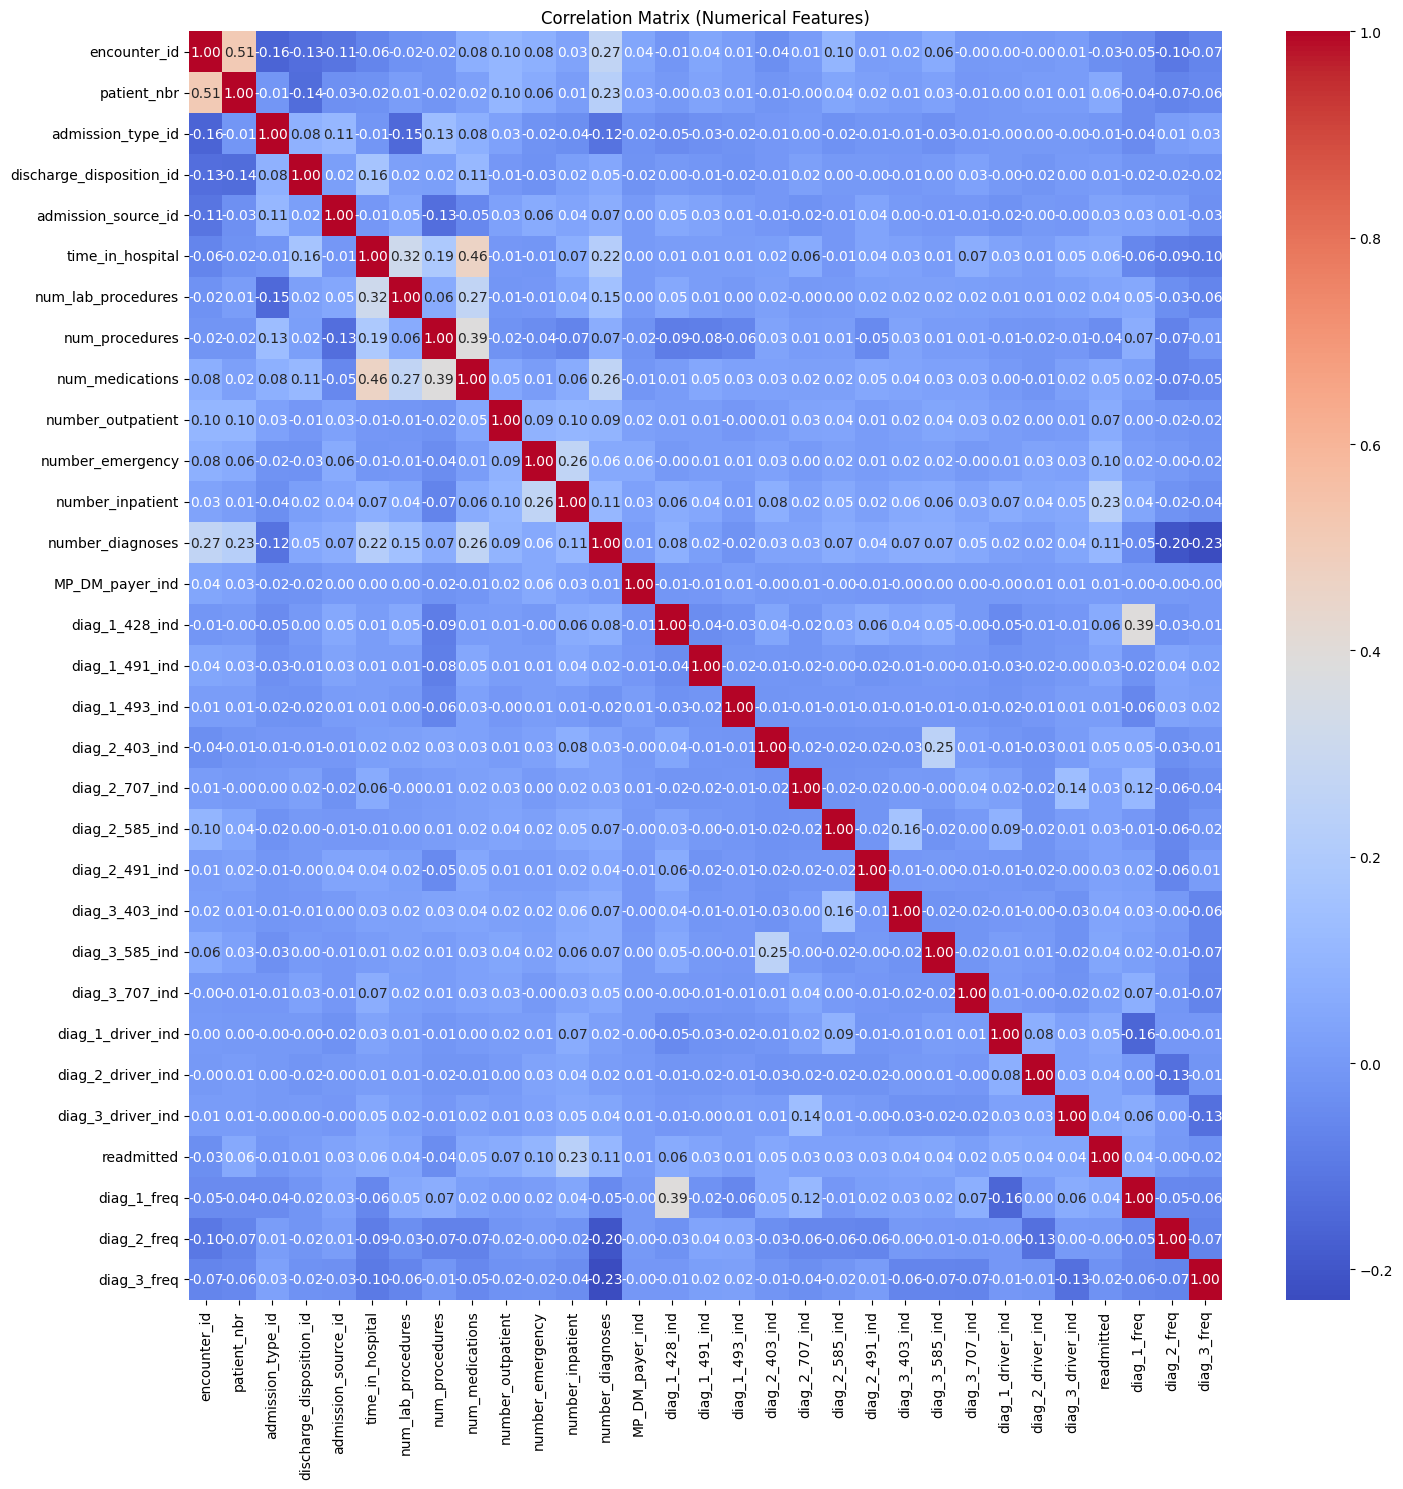

In [33]:
plt.figure(figsize=(15, 15))
corr = train_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (Numerical Features)')
plt.tight_layout()
plt.show()

## Modeling

In [35]:
cols_to_drop = ['patient_nbr', 'encounter_id']
X_train = train_df.drop(columns=cols_to_drop + ['readmitted'])
y_train = train_df['readmitted']

cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

X_test = test_df.drop(columns=cols_to_drop + ['readmitted'])
y_test = test_df['readmitted']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

### Random Forest

In [96]:
param_grid = [
    {'n_estimators': 50, 'max_depth': 25, 'ccp_alpha': 0.0},
    {'n_estimators': 100, 'max_depth': 25, 'ccp_alpha': 0.0},
    {'n_estimators': 150, 'max_depth': 25, 'ccp_alpha': 0.0},
    {'n_estimators': 50, 'max_depth': 50, 'ccp_alpha': 0.0},
    {'n_estimators': 100, 'max_depth': 50, 'ccp_alpha': 0.0},
    {'n_estimators': 150, 'max_depth': 50, 'ccp_alpha': 0.0},
    {'n_estimators': 50, 'max_depth': 75, 'ccp_alpha': 0.0},
    {'n_estimators': 100, 'max_depth': 75, 'ccp_alpha': 0.0},
    {'n_estimators': 150, 'max_depth': 75, 'ccp_alpha': 0.0},
    {'n_estimators': 50, 'max_depth': 25, 'ccp_alpha': 0.001},
    {'n_estimators': 100, 'max_depth': 25, 'ccp_alpha': 0.001},
    {'n_estimators': 150, 'max_depth': 25, 'ccp_alpha': 0.001},
    {'n_estimators': 50, 'max_depth': 50, 'ccp_alpha': 0.001},
    {'n_estimators': 100, 'max_depth': 50, 'ccp_alpha': 0.001},
    {'n_estimators': 150, 'max_depth': 50, 'ccp_alpha': 0.001},
    {'n_estimators': 50, 'max_depth': 75, 'ccp_alpha': 0.001},
    {'n_estimators': 100, 'max_depth': 75, 'ccp_alpha': 0.001},
    {'n_estimators': 150, 'max_depth': 75, 'ccp_alpha': 0.001},
    {'n_estimators': 50, 'max_depth': 25, 'ccp_alpha': 0.003},
    {'n_estimators': 100, 'max_depth': 25, 'ccp_alpha': 0.003},
    {'n_estimators': 150, 'max_depth': 25, 'ccp_alpha': 0.003},
    {'n_estimators': 50, 'max_depth': 50, 'ccp_alpha': 0.003},
    {'n_estimators': 100, 'max_depth': 50, 'ccp_alpha': 0.003},
    {'n_estimators': 150, 'max_depth': 50, 'ccp_alpha': 0.003},
    {'n_estimators': 50, 'max_depth': 75, 'ccp_alpha': 0.003},
    {'n_estimators': 100, 'max_depth': 75, 'ccp_alpha': 0.003},
    {'n_estimators': 150, 'max_depth': 75, 'ccp_alpha': 0.003},
]


In [97]:
results_list = []

for params in param_grid:
    exp_name = f"nest_{params['n_estimators']}_maxde_{params['max_depth']}_ccp_{params['ccp_alpha']}"
    print(f"Test: {exp_name}")
    cv = StratifiedKFold(n_splits=5, shuffle=True)

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_train_cv, X_val_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model_pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', RandomForestClassifier(
                n_estimators=params['n_estimators'],
                max_depth=params['max_depth'],
                ccp_alpha=params['ccp_alpha'],
                n_jobs=-1
            ))
        ])

        model_pipeline.fit(X_train_cv, y_train_cv)
        y_pred_cv = model_pipeline.predict(X_val_cv)

        f1 = f1_score(y_val_cv, y_pred_cv, average='macro')
        acc = accuracy_score(y_val_cv, y_pred_cv)
        recall = recall_score(y_val_cv, y_pred_cv, average='macro')
        precision = precision_score(y_val_cv, y_pred_cv, average='macro', zero_division=0)

        results_list.append({
            'experiment': exp_name,
            'fold': fold+1,
            'f1_macro': f1,
            'accuracy': acc,
            'recall_macro': recall,
            'precision_macro': precision
        })

Test: nest_50_maxde_25_ccp_0.0
Test: nest_100_maxde_25_ccp_0.0
Test: nest_150_maxde_25_ccp_0.0
Test: nest_50_maxde_50_ccp_0.0
Test: nest_100_maxde_50_ccp_0.0
Test: nest_150_maxde_50_ccp_0.0
Test: nest_50_maxde_75_ccp_0.0
Test: nest_100_maxde_75_ccp_0.0
Test: nest_150_maxde_75_ccp_0.0
Test: nest_50_maxde_25_ccp_0.001
Test: nest_100_maxde_25_ccp_0.001
Test: nest_150_maxde_25_ccp_0.001
Test: nest_50_maxde_50_ccp_0.001
Test: nest_100_maxde_50_ccp_0.001
Test: nest_150_maxde_50_ccp_0.001
Test: nest_50_maxde_75_ccp_0.001
Test: nest_100_maxde_75_ccp_0.001
Test: nest_150_maxde_75_ccp_0.001
Test: nest_50_maxde_25_ccp_0.003
Test: nest_100_maxde_25_ccp_0.003
Test: nest_150_maxde_25_ccp_0.003
Test: nest_50_maxde_50_ccp_0.003
Test: nest_100_maxde_50_ccp_0.003
Test: nest_150_maxde_50_ccp_0.003
Test: nest_50_maxde_75_ccp_0.003
Test: nest_100_maxde_75_ccp_0.003
Test: nest_150_maxde_75_ccp_0.003


In [103]:
results_df = pd.DataFrame(results_list)

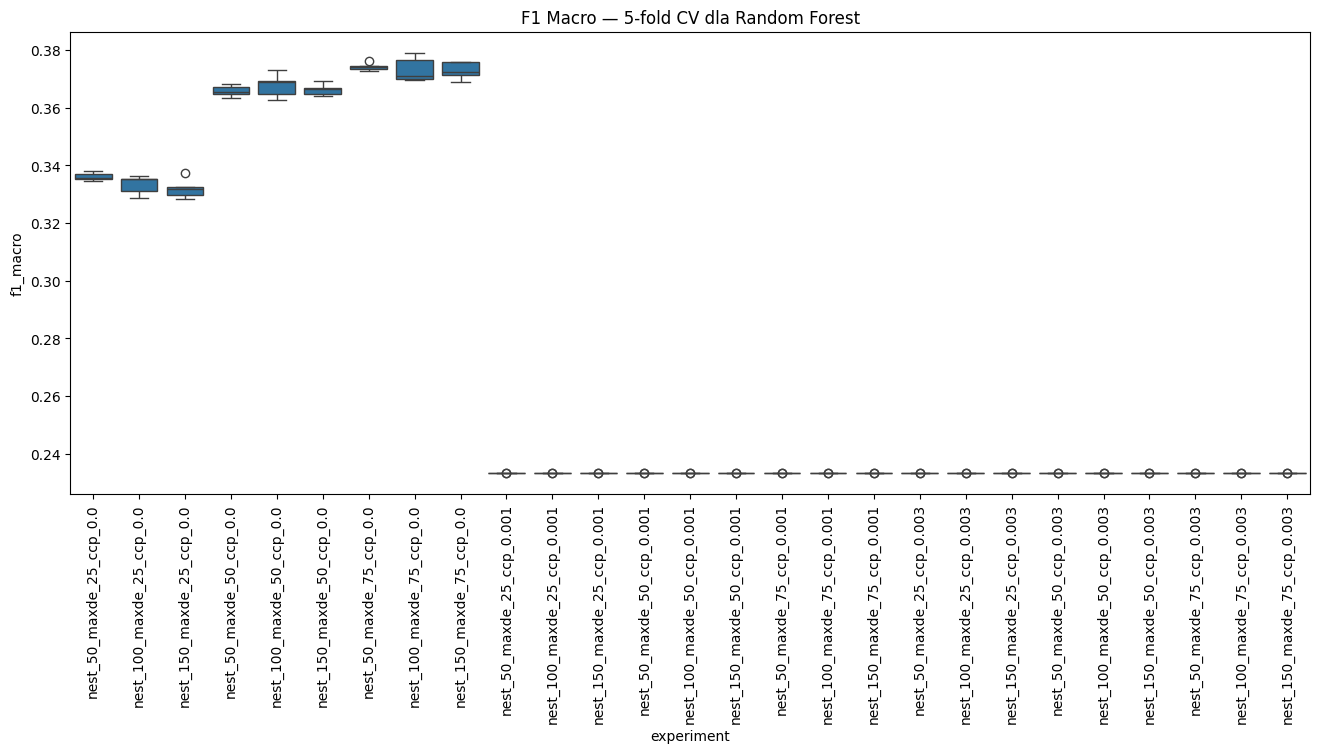

In [104]:
plt.figure(figsize=(16,6))
sns.boxplot(data=results_df, x='experiment', y='f1_macro')
plt.xticks(rotation=90)
plt.title("F1 Macro — 5-fold CV dla Random Forest")
plt.show()

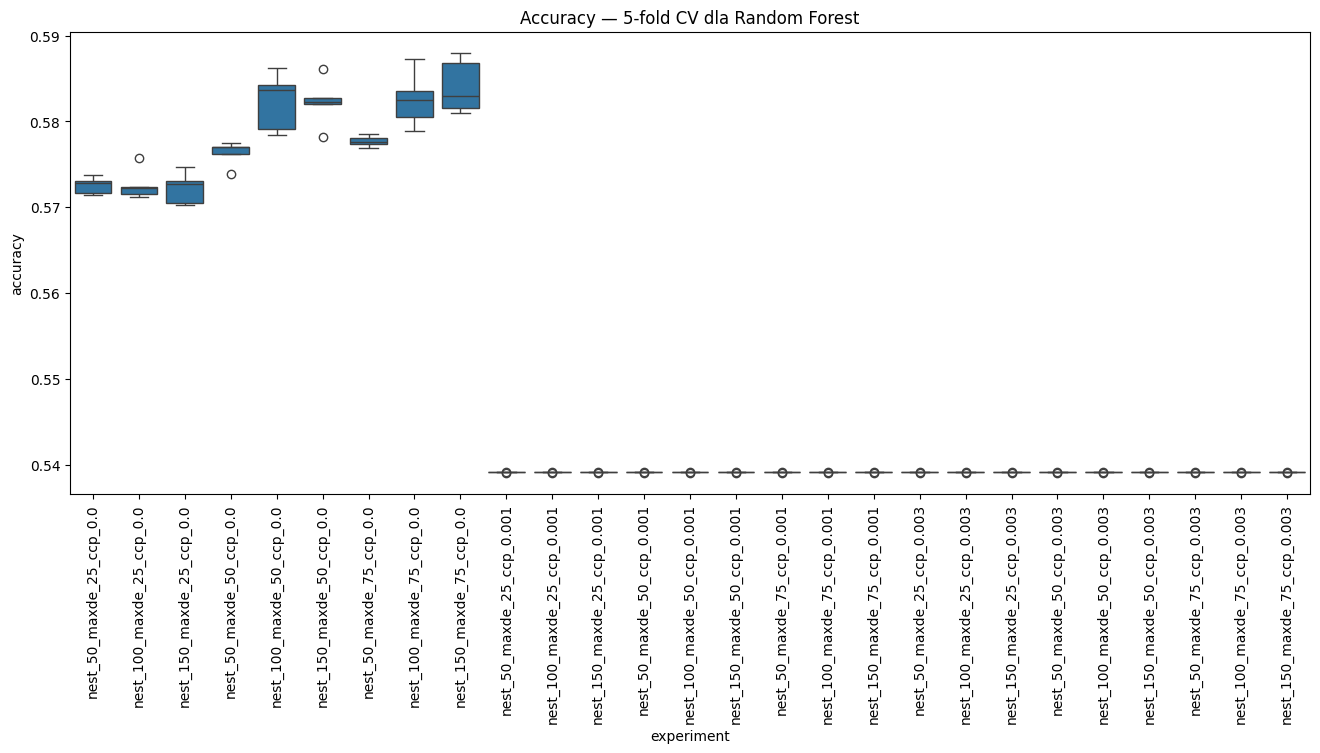

In [100]:
plt.figure(figsize=(16,6))
sns.boxplot(data=results_df, x='experiment', y='accuracy')
plt.xticks(rotation=90)
plt.title("Accuracy — 5-fold CV dla Random Forest")
plt.show()

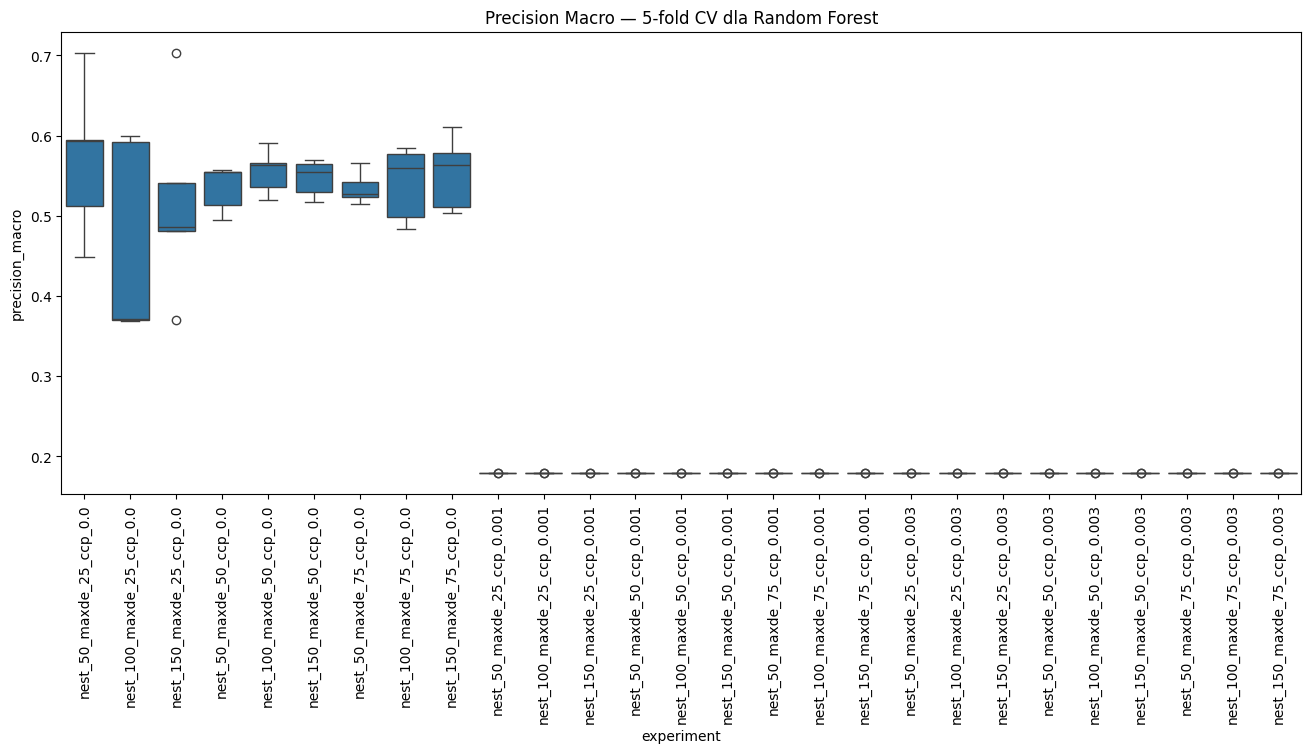

In [101]:
plt.figure(figsize=(16,6))
sns.boxplot(data=results_df, x='experiment', y='precision_macro')
plt.xticks(rotation=90)
plt.title("Precision Macro — 5-fold CV dla Random Forest")
plt.show()

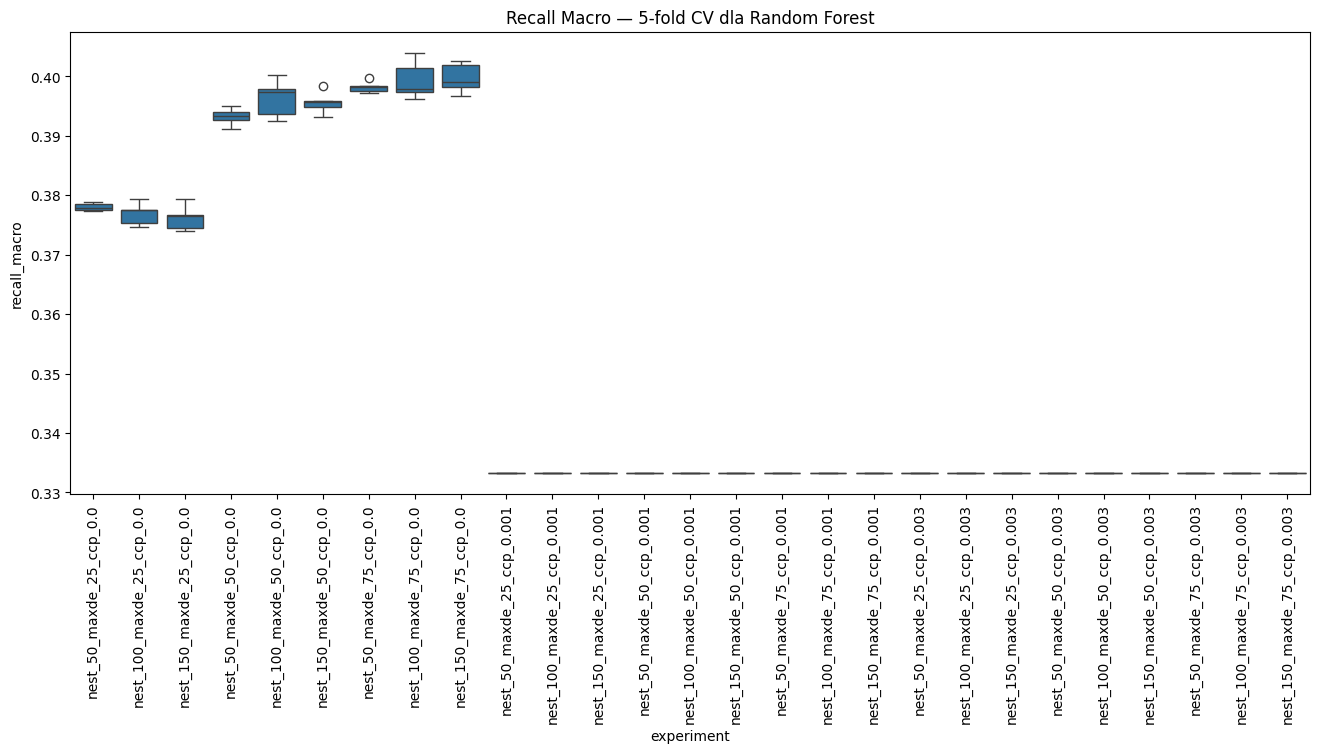

In [102]:
plt.figure(figsize=(16,6))
sns.boxplot(data=results_df, x='experiment', y='recall_macro')
plt.xticks(rotation=90)
plt.title("Recall Macro — 5-fold CV dla Random Forest")
plt.show()

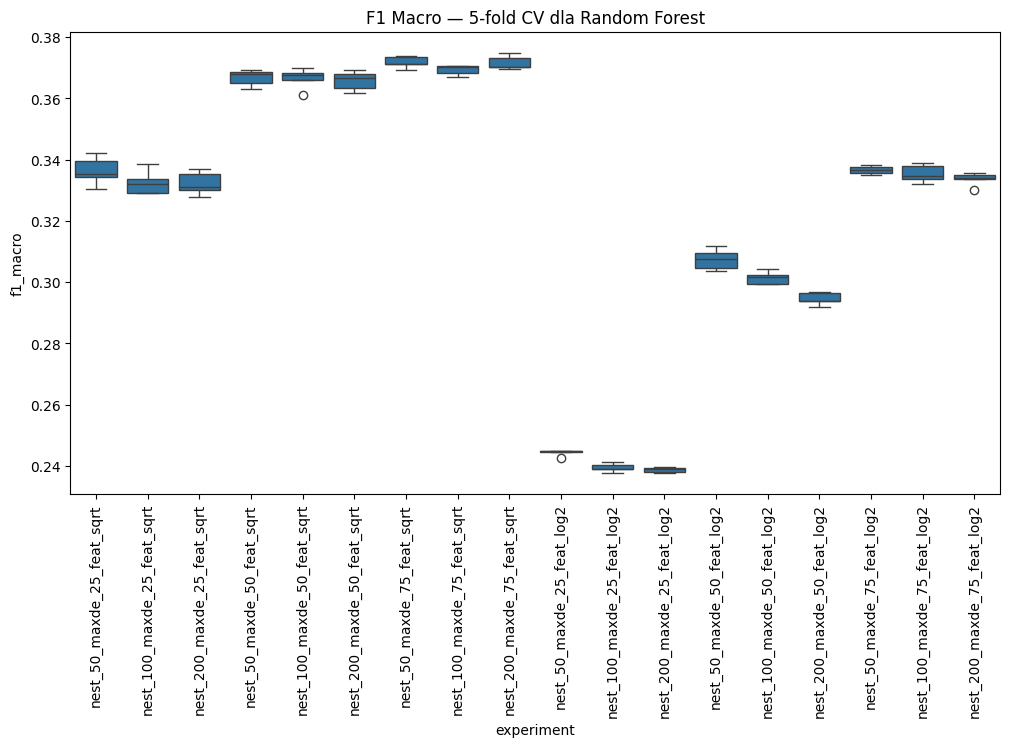

In [79]:
plt.figure(figsize=(12,6))
sns.boxplot(data=results_df, x='experiment', y='f1_macro')
plt.xticks(rotation=90)
plt.title("F1 Macro — 5-fold CV dla Random Forest")
plt.show()

## AdaBoost

In [105]:
param_grid_adaboost = [
    {'n_estimators': 50, 'learning_rate': 1.3, 'max_depth': 1},
    {'n_estimators': 100, 'learning_rate': 1.3, 'max_depth': 1},
    {'n_estimators': 150, 'learning_rate': 1.3, 'max_depth': 1},
    {'n_estimators': 200, 'learning_rate': 1.3, 'max_depth': 1},
    {'n_estimators': 50, 'learning_rate': 1.0, 'max_depth': 1},
    {'n_estimators': 100, 'learning_rate': 1.0, 'max_depth': 1},
    {'n_estimators': 150, 'learning_rate': 1.0, 'max_depth': 1},
    {'n_estimators': 200, 'learning_rate': 1.0, 'max_depth': 1},
    {'n_estimators': 50, 'learning_rate': 0.7, 'max_depth': 1},
    {'n_estimators': 100, 'learning_rate': 0.7, 'max_depth': 1},
    {'n_estimators': 150, 'learning_rate': 0.7, 'max_depth': 1},
    {'n_estimators': 200, 'learning_rate': 0.7, 'max_depth': 1},

    {'n_estimators': 50, 'learning_rate': 1.3, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 1.3, 'max_depth': 2},
    {'n_estimators': 150, 'learning_rate': 1.3, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 1.3, 'max_depth': 2},
    {'n_estimators': 50, 'learning_rate': 1.0, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 1.0, 'max_depth': 2},
    {'n_estimators': 150, 'learning_rate': 1.0, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 1.0, 'max_depth': 2},
    {'n_estimators': 50, 'learning_rate': 0.7, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.7, 'max_depth': 2},
    {'n_estimators': 150, 'learning_rate': 0.7, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.7, 'max_depth': 2},
]

In [107]:
ada_results_list = []

for params in param_grid_adaboost:
    exp_name = f"nest_{params['n_estimators']}_lr_{params['learning_rate']}_maxd_{params['max_depth']}"
    print(f"Test: {exp_name}")
    cv = StratifiedKFold(n_splits=5, shuffle=True)

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_train_cv, X_val_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model_pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', AdaBoostClassifier(
                estimator=DecisionTreeClassifier(max_depth=params['max_depth']),
                n_estimators=params['n_estimators'],
                learning_rate=params['learning_rate'],
                random_state=42
            ))
        ])

        model_pipeline.fit(X_train_cv, y_train_cv)
        y_pred_cv = model_pipeline.predict(X_val_cv)

        f1 = f1_score(y_val_cv, y_pred_cv, average='macro')
        acc = accuracy_score(y_val_cv, y_pred_cv)
        recall = recall_score(y_val_cv, y_pred_cv, average='macro')
        precision = precision_score(y_val_cv, y_pred_cv, average='macro', zero_division=0)

        ada_results_list.append({
            'experiment': exp_name,
            'fold': fold+1,
            'f1_macro': f1,
            'accuracy': acc,
            'recall_macro': recall,
            'precision_macro': precision
        })

Test: nest_50_lr_1.3_maxd_1
Test: nest_100_lr_1.3_maxd_1
Test: nest_150_lr_1.3_maxd_1
Test: nest_200_lr_1.3_maxd_1
Test: nest_50_lr_1.0_maxd_1
Test: nest_100_lr_1.0_maxd_1
Test: nest_150_lr_1.0_maxd_1
Test: nest_200_lr_1.0_maxd_1
Test: nest_50_lr_0.7_maxd_1
Test: nest_100_lr_0.7_maxd_1
Test: nest_150_lr_0.7_maxd_1
Test: nest_200_lr_0.7_maxd_1
Test: nest_50_lr_1.3_maxd_2
Test: nest_100_lr_1.3_maxd_2
Test: nest_150_lr_1.3_maxd_2
Test: nest_200_lr_1.3_maxd_2
Test: nest_50_lr_1.0_maxd_2
Test: nest_100_lr_1.0_maxd_2
Test: nest_150_lr_1.0_maxd_2
Test: nest_200_lr_1.0_maxd_2
Test: nest_50_lr_0.7_maxd_2
Test: nest_100_lr_0.7_maxd_2
Test: nest_150_lr_0.7_maxd_2
Test: nest_200_lr_0.7_maxd_2


In [108]:
ada_results_df = pd.DataFrame(ada_results_list)

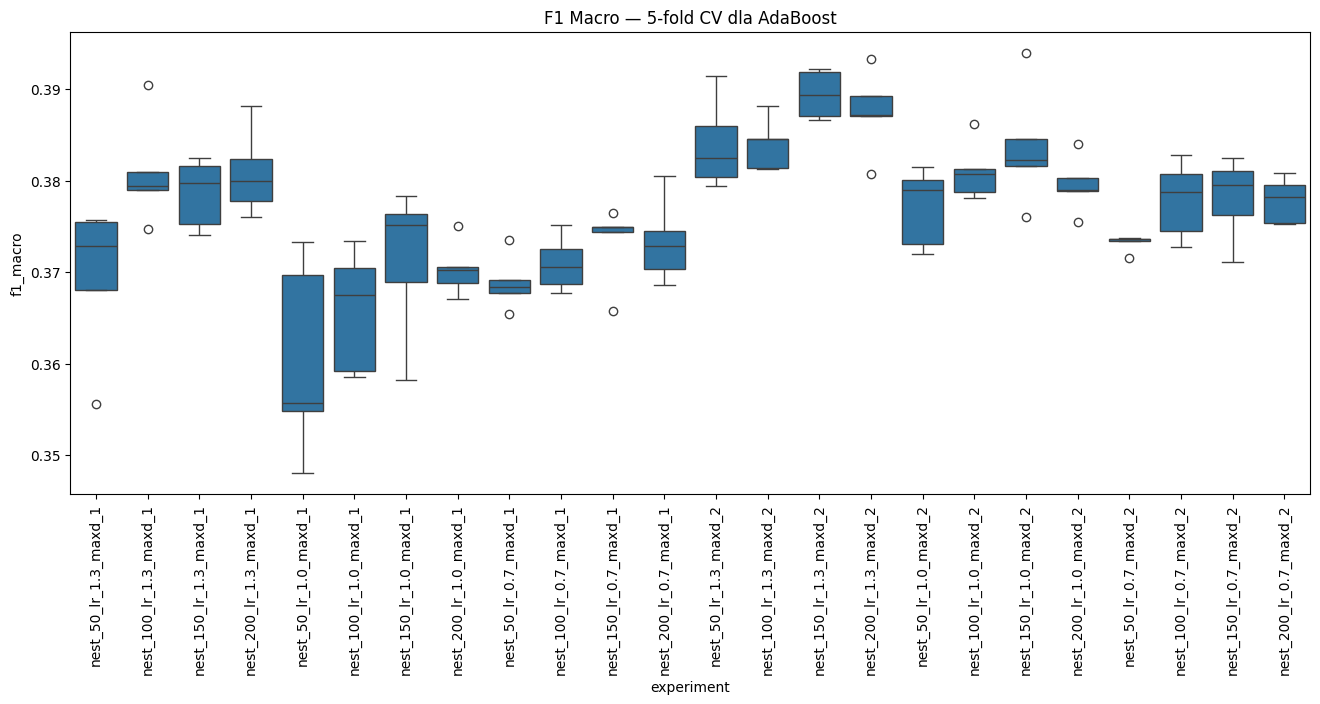

In [109]:
plt.figure(figsize=(16,6))
sns.boxplot(data=ada_results_df, x='experiment', y='f1_macro')
plt.xticks(rotation=90)
plt.title("F1 Macro — 5-fold CV dla AdaBoost")
plt.show()

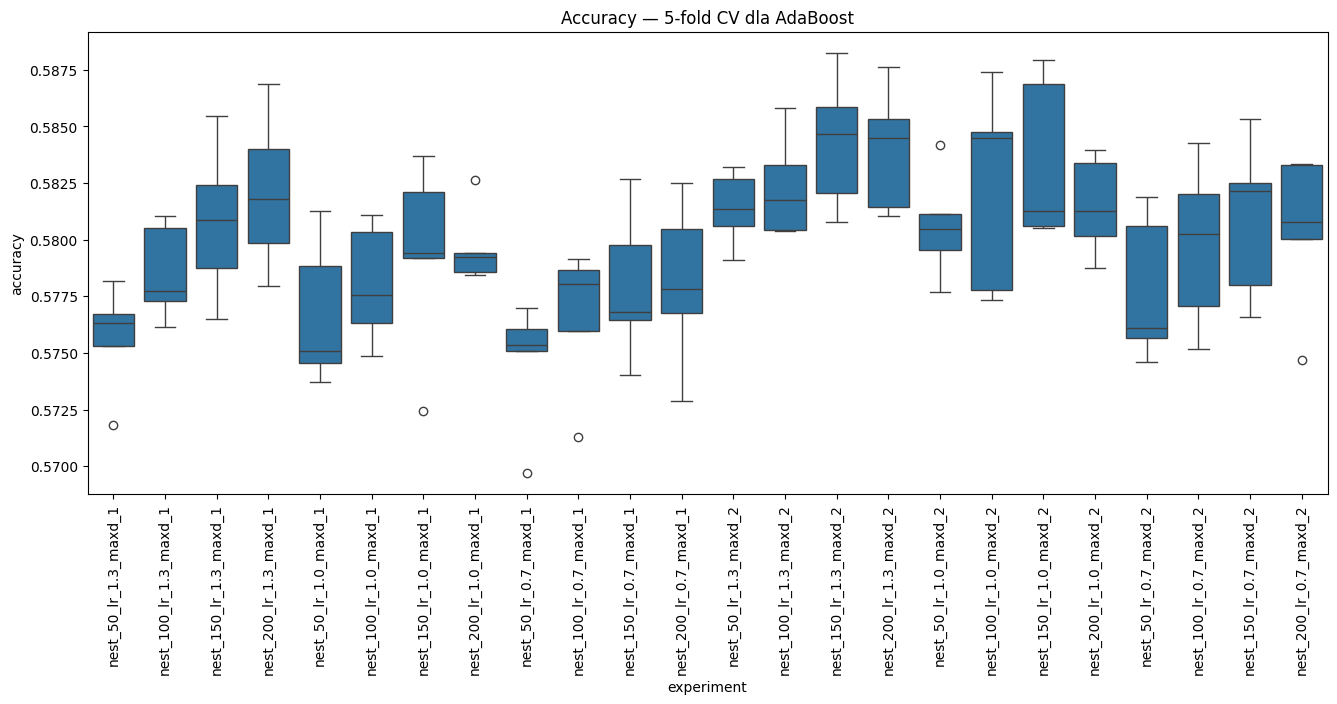

In [110]:
plt.figure(figsize=(16,6))
sns.boxplot(data=ada_results_df, x='experiment', y='accuracy')
plt.xticks(rotation=90)
plt.title("Accuracy — 5-fold CV dla AdaBoost")
plt.show()

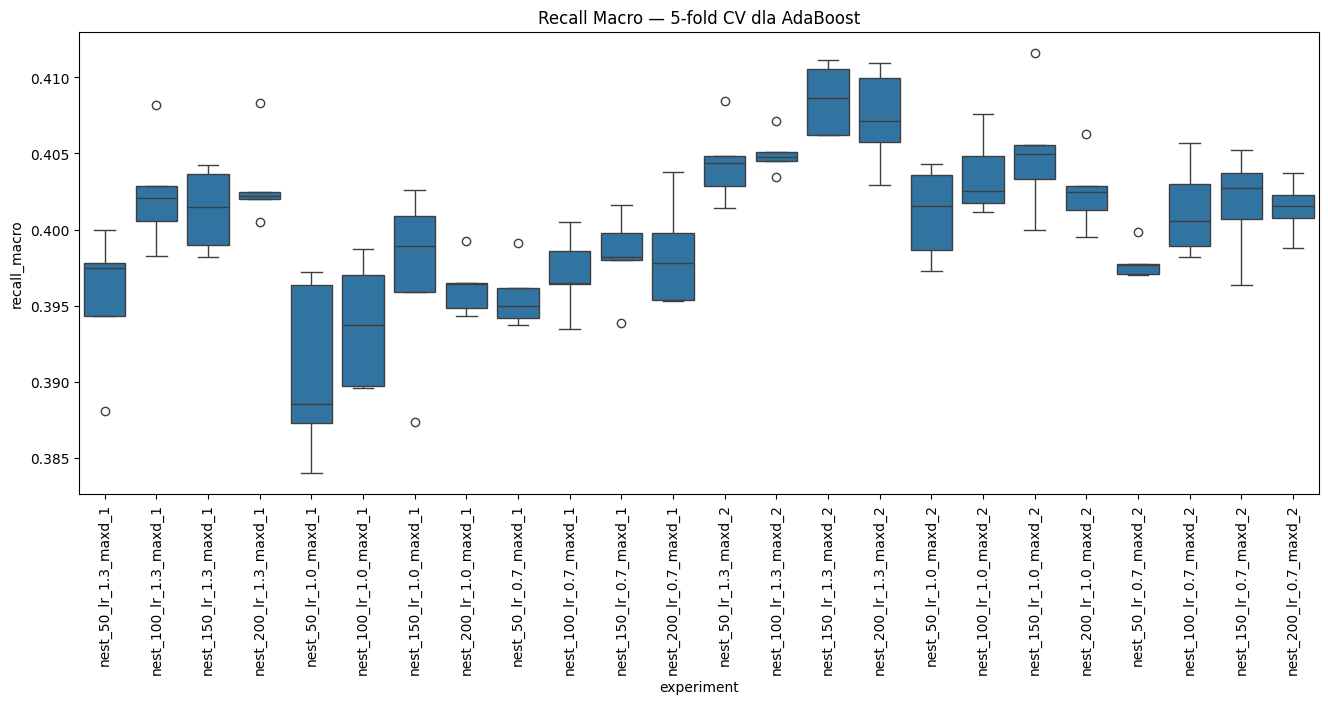

In [111]:
plt.figure(figsize=(16,6))
sns.boxplot(data=ada_results_df, x='experiment', y='recall_macro')
plt.xticks(rotation=90)
plt.title("Recall Macro — 5-fold CV dla AdaBoost")
plt.show()

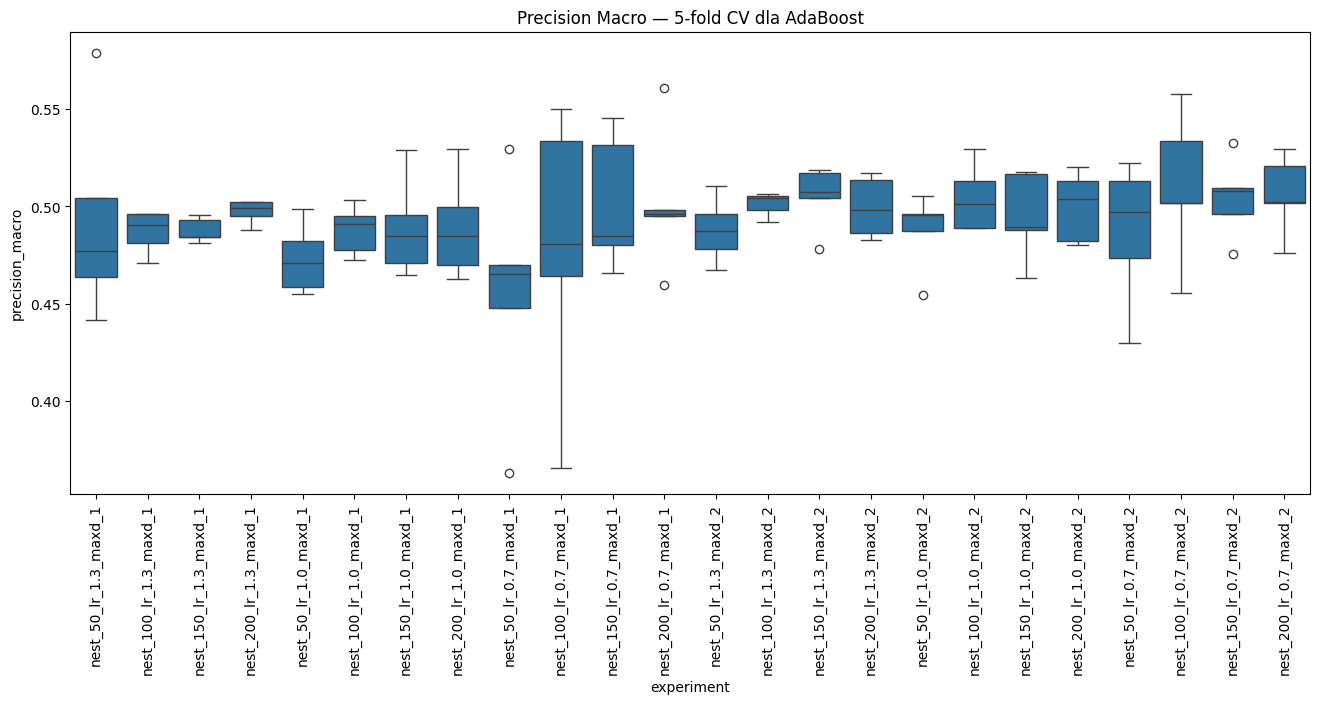

In [112]:
plt.figure(figsize=(16,6))
sns.boxplot(data=ada_results_df, x='experiment', y='precision_macro')
plt.xticks(rotation=90)
plt.title("Precision Macro — 5-fold CV dla AdaBoost")
plt.show()

## XGBoost

In [22]:
param_grid_xgboost = [
    {'n_estimators': n, 'max_depth': d, 'learning_rate': lr}
    for n in [50, 100, 150]
    for d in [3, 5, 7, 9]
    for lr in [1, 0.7, 0.5, 0.3]
]

In [23]:
xgb_results_list = []

for params in param_grid_xgboost:
    exp_name = f"nest_{params['n_estimators']}_maxd_{params['max_depth']}_lr_{params['learning_rate']}"

    print(f"Test: {exp_name}")
    cv = StratifiedKFold(n_splits=5, shuffle=True)

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_train_cv, X_val_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model_pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', XGBClassifier(
                n_estimators=params['n_estimators'],
                max_depth=params['max_depth'],
                learning_rate=params['learning_rate'],
                eval_metric='mlogloss',
                n_jobs=-1,
            ))
        ])

        model_pipeline.fit(X_train_cv, y_train_cv)
        y_pred_cv = model_pipeline.predict(X_val_cv)

        f1 = f1_score(y_val_cv, y_pred_cv, average='macro')
        acc = accuracy_score(y_val_cv, y_pred_cv)
        recall = recall_score(y_val_cv, y_pred_cv, average='macro')
        precision = precision_score(y_val_cv, y_pred_cv, average='macro', zero_division=0)

        xgb_results_list.append({
            'experiment': exp_name,
            'fold': fold+1,
            'f1_macro': f1,
            'accuracy': acc,
            'recall_macro': recall,
            'precision_macro': precision
        })

Test: nest_50_maxd_3_lr_1
Test: nest_50_maxd_3_lr_0.7
Test: nest_50_maxd_3_lr_0.5
Test: nest_50_maxd_3_lr_0.3
Test: nest_50_maxd_5_lr_1
Test: nest_50_maxd_5_lr_0.7
Test: nest_50_maxd_5_lr_0.5
Test: nest_50_maxd_5_lr_0.3
Test: nest_50_maxd_7_lr_1
Test: nest_50_maxd_7_lr_0.7
Test: nest_50_maxd_7_lr_0.5
Test: nest_50_maxd_7_lr_0.3
Test: nest_50_maxd_9_lr_1
Test: nest_50_maxd_9_lr_0.7
Test: nest_50_maxd_9_lr_0.5
Test: nest_50_maxd_9_lr_0.3
Test: nest_100_maxd_3_lr_1
Test: nest_100_maxd_3_lr_0.7
Test: nest_100_maxd_3_lr_0.5
Test: nest_100_maxd_3_lr_0.3
Test: nest_100_maxd_5_lr_1
Test: nest_100_maxd_5_lr_0.7
Test: nest_100_maxd_5_lr_0.5
Test: nest_100_maxd_5_lr_0.3
Test: nest_100_maxd_7_lr_1
Test: nest_100_maxd_7_lr_0.7
Test: nest_100_maxd_7_lr_0.5
Test: nest_100_maxd_7_lr_0.3
Test: nest_100_maxd_9_lr_1
Test: nest_100_maxd_9_lr_0.7
Test: nest_100_maxd_9_lr_0.5
Test: nest_100_maxd_9_lr_0.3
Test: nest_150_maxd_3_lr_1
Test: nest_150_maxd_3_lr_0.7
Test: nest_150_maxd_3_lr_0.5
Test: nest_150_maxd

In [24]:
xgb_results_df = pd.DataFrame(xgb_results_list)

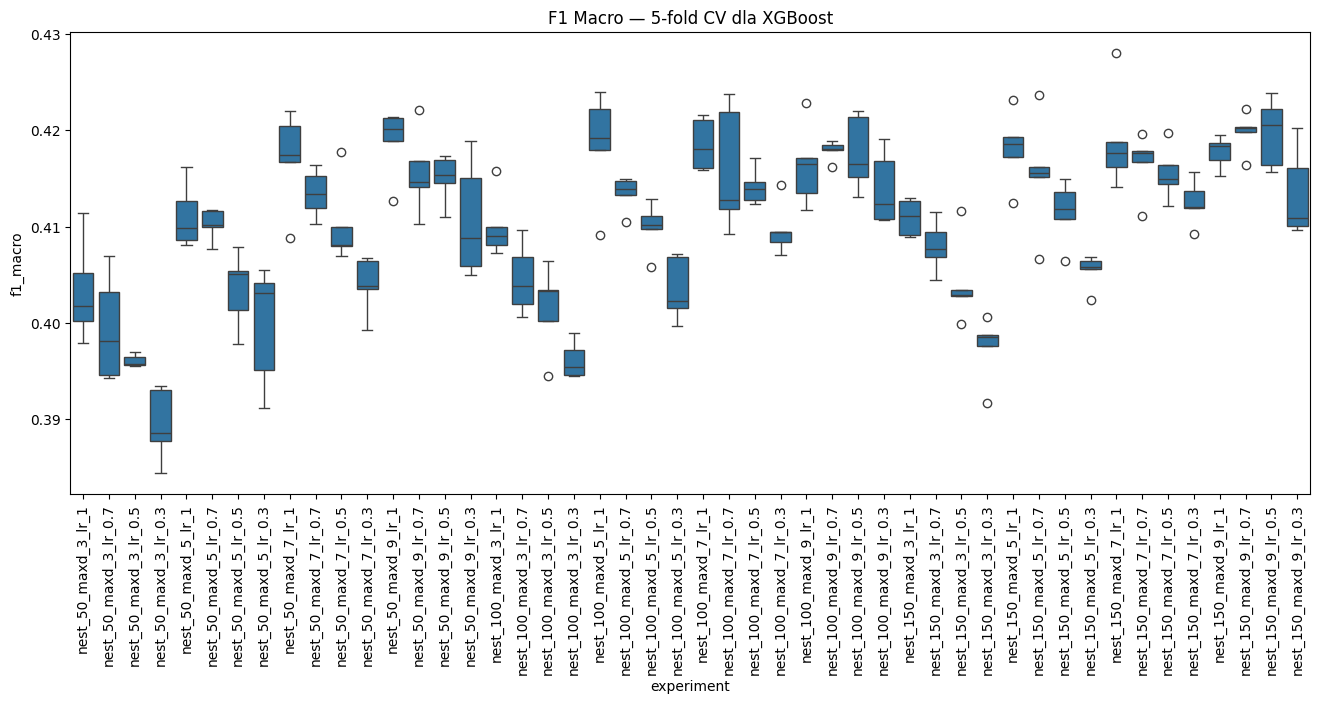

In [25]:
plt.figure(figsize=(16,6))
sns.boxplot(data=xgb_results_df, x='experiment', y='f1_macro')
plt.xticks(rotation=90)
plt.title("F1 Macro — 5-fold CV dla XGBoost")
plt.show()

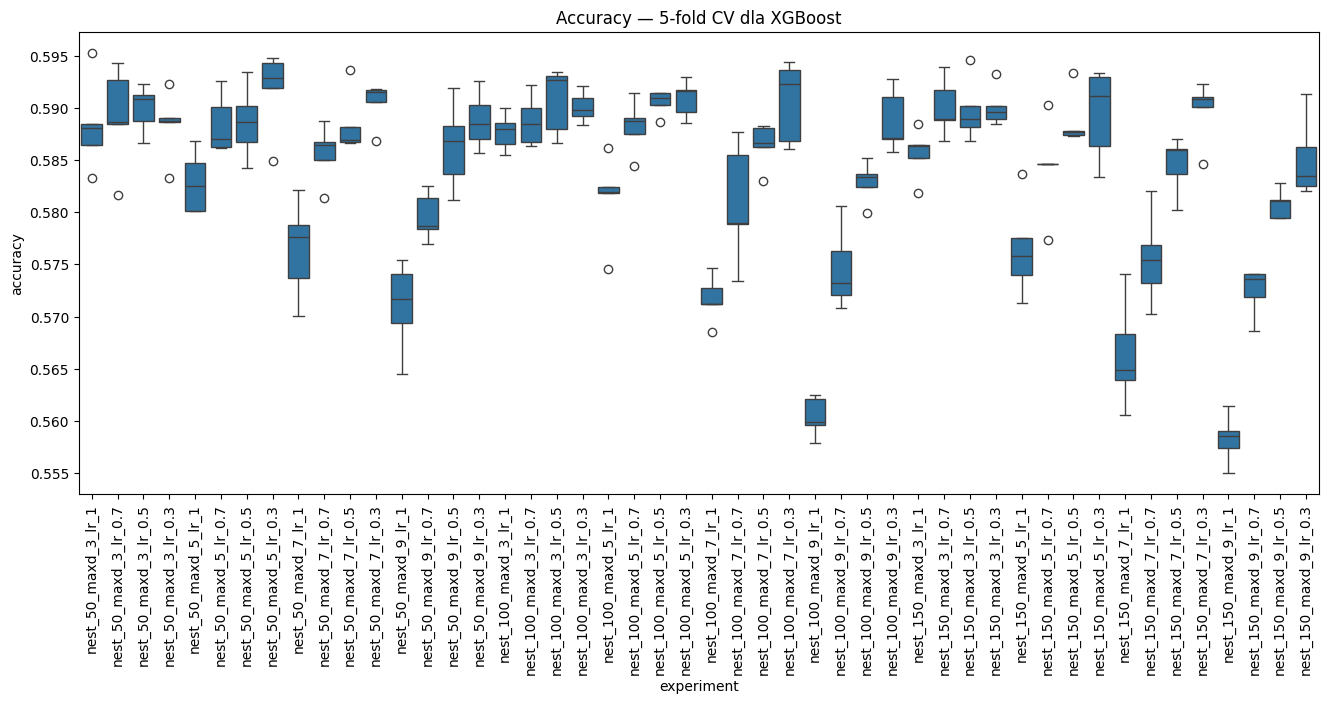

In [26]:
plt.figure(figsize=(16,6))
sns.boxplot(data=xgb_results_df, x='experiment', y='accuracy')
plt.xticks(rotation=90)
plt.title("Accuracy — 5-fold CV dla XGBoost")
plt.show()

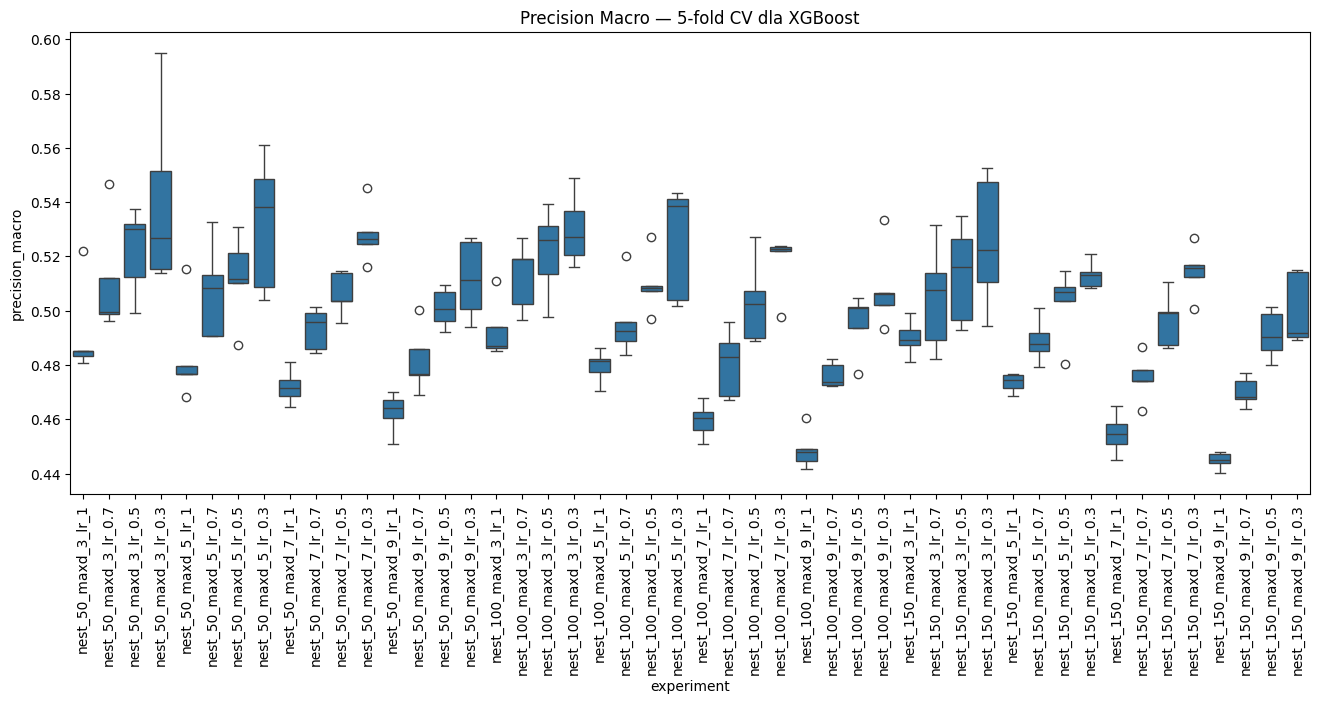

In [27]:
plt.figure(figsize=(16,6))
sns.boxplot(data=xgb_results_df, x='experiment', y='precision_macro')
plt.xticks(rotation=90)
plt.title("Precision Macro — 5-fold CV dla XGBoost")
plt.show()

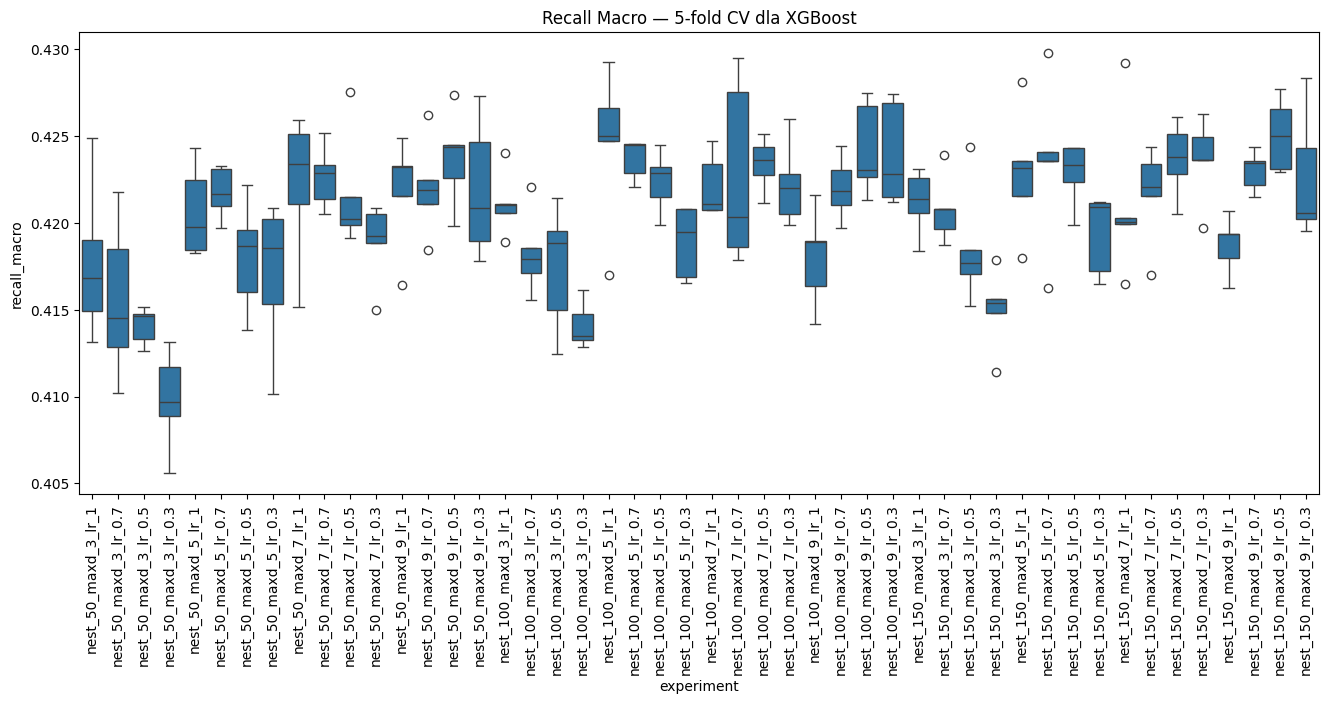

In [28]:
plt.figure(figsize=(16,6))
sns.boxplot(data=xgb_results_df, x='experiment', y='recall_macro')
plt.xticks(rotation=90)
plt.title("Recall Macro — 5-fold CV dla XGBoost")
plt.show()

# Analiza działania zespołów klasyfikatorów

### Skuteczność

In [36]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=75,
        ccp_alpha=0.0,
        max_features='sqrt',
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

rf_confusion_matrix = confusion_matrix(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred, average='macro')
rf_acc = accuracy_score(y_test, y_pred)
rf_recall = recall_score(y_test, y_pred, average='macro')
rf_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)

In [37]:
ada_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2),
        n_estimators=150,
        learning_rate=1.3
    ))
])

ada_pipeline.fit(X_train, y_train)
y_pred_ada = ada_pipeline.predict(X_test)

ada_confusion_matrix = confusion_matrix(y_test, y_pred_ada)
ada_f1 = f1_score(y_test, y_pred_ada, average='macro')
ada_acc = accuracy_score(y_test, y_pred_ada)
ada_recall = recall_score(y_test, y_pred_ada, average='macro')
ada_precision = precision_score(y_test, y_pred_ada, average='macro', zero_division=0)

In [38]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=150,
        max_depth=9,
        learning_rate=0.5,
        eval_metric='mlogloss',
        n_jobs=-1,
    ))
])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)

xgb_confusion_matrix = confusion_matrix(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb, average='macro')
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb, average='macro')
xgb_precision = precision_score(y_test, y_pred_xgb, average='macro', zero_division=0)

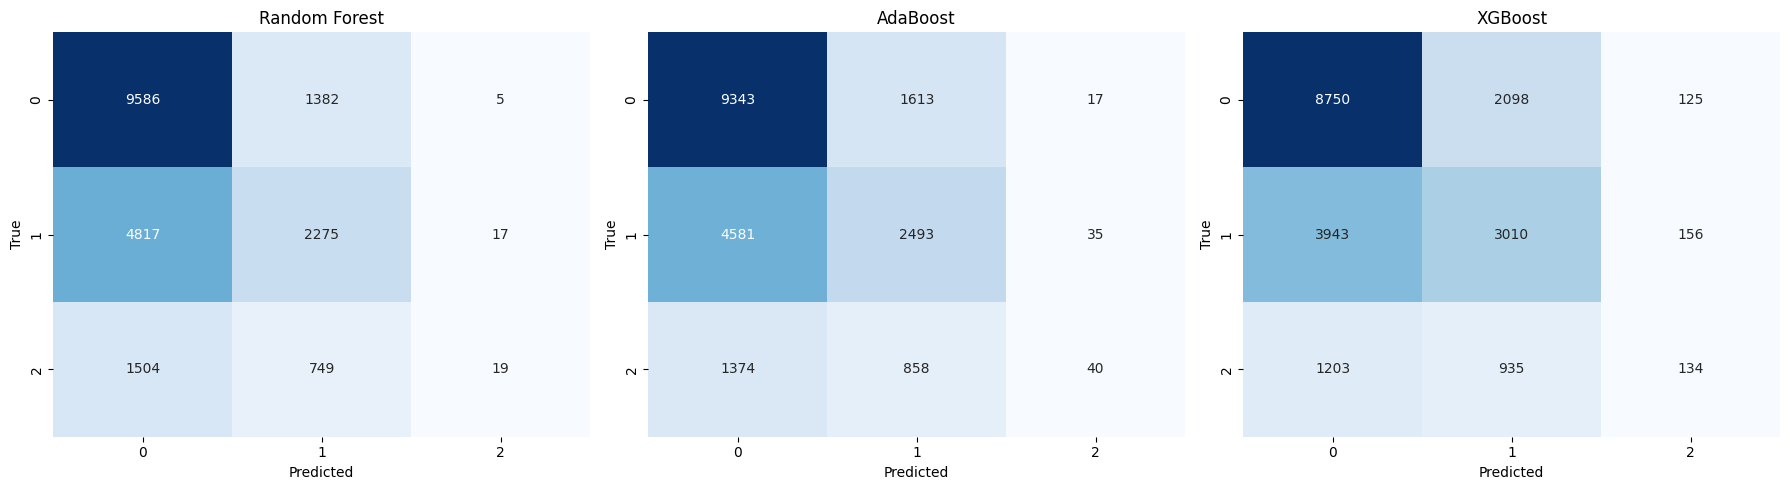

In [41]:
conf_matrices = [
    (rf_confusion_matrix, 'Random Forest'),
    (ada_confusion_matrix, 'AdaBoost'),
    (xgb_confusion_matrix, 'XGBoost')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (cm, title) in zip(axes, conf_matrices):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()

In [42]:
results_df = pd.DataFrame({
    'Model': ['Random Forest', 'AdaBoost', 'XGBoost'],
    'F1 Macro': [rf_f1, ada_f1, xgb_f1],
    'Accuracy': [rf_acc, ada_acc, xgb_acc],
    'Recall Macro': [rf_recall, ada_recall, xgb_recall],
    'Precision Macro': [rf_precision, ada_precision, xgb_precision]
})

results_df = results_df.round(4)

print(results_df)

           Model  F1 Macro  Accuracy  Recall Macro  Precision Macro
0  Random Forest    0.3749    0.5837        0.4007           0.5275
1       AdaBoost    0.3860    0.5835        0.4066           0.5159
2        XGBoost    0.4204    0.5844        0.4266           0.4836


### Zrozumiałość

### RF

In [49]:
shap.initjs()

preprocessor = rf_pipeline.named_steps['preprocessor']
model = rf_pipeline.named_steps['classifier']

X_test_processed = preprocessor.transform(X_test)
X_test_processed_dense = X_test_processed.toarray()

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_processed_dense, approximate=True)

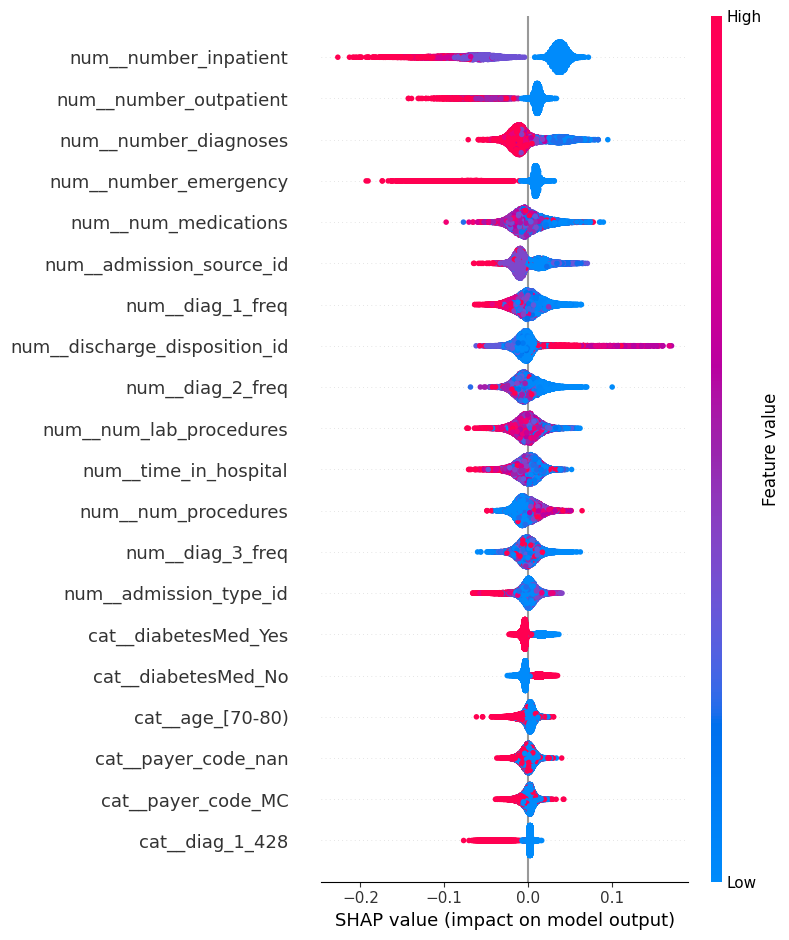

In [50]:
shap.summary_plot(shap_values[:,:,0], X_test_processed_dense, feature_names=preprocessor.get_feature_names_out())

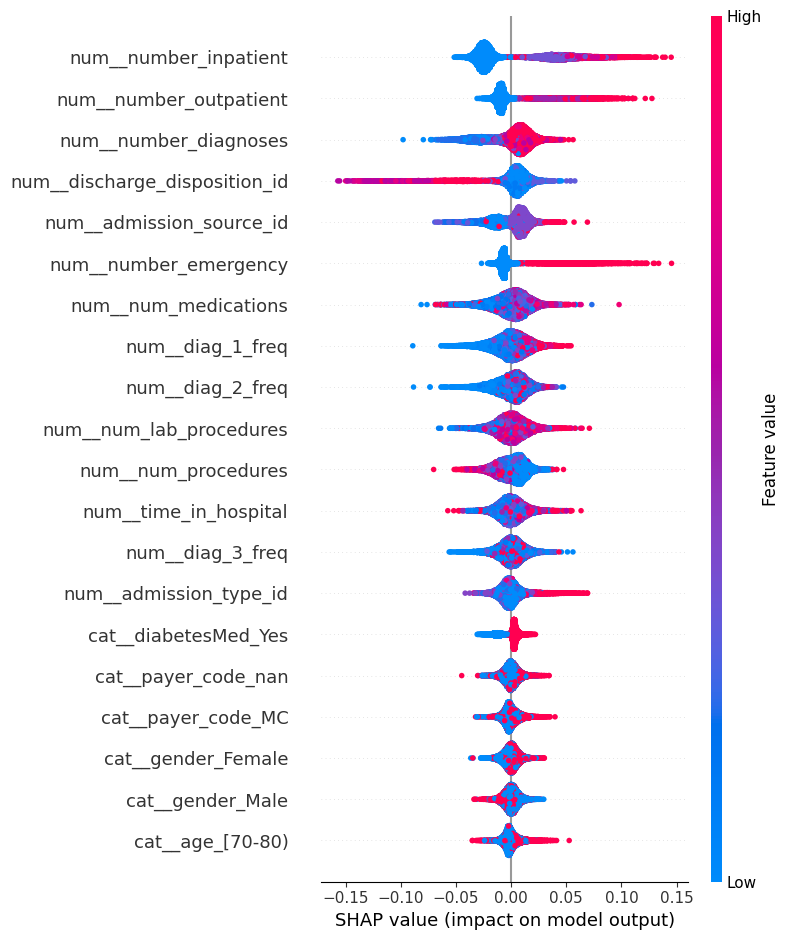

In [51]:
shap.summary_plot(shap_values[:,:,1], X_test_processed_dense, feature_names=preprocessor.get_feature_names_out())

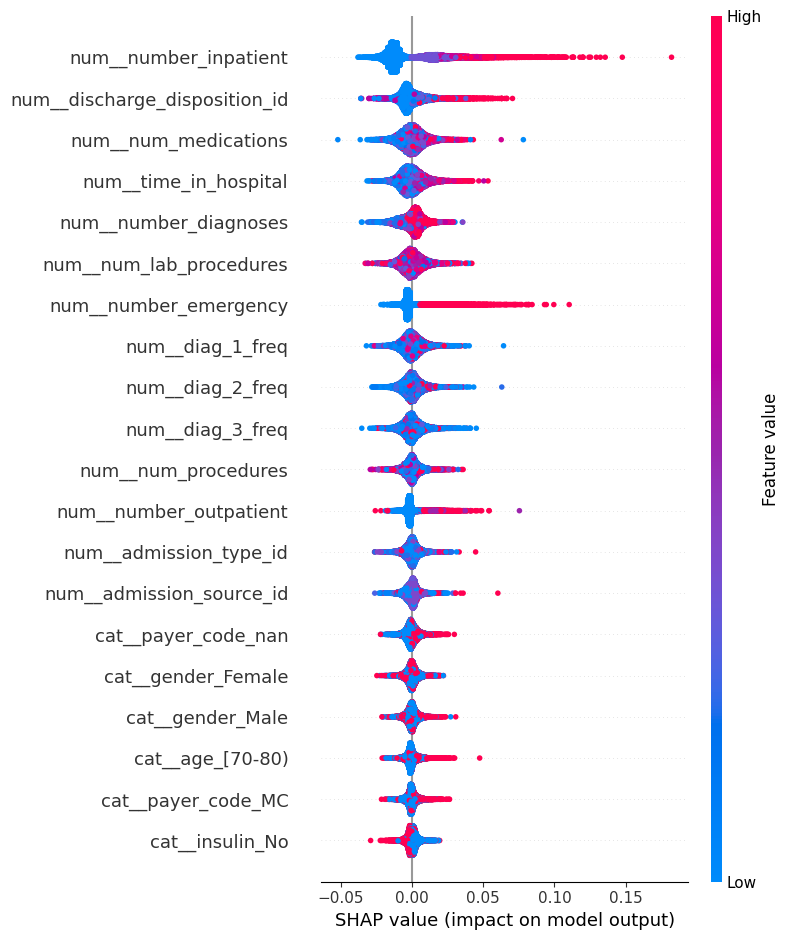

In [52]:
shap.summary_plot(shap_values[:,:,2], X_test_processed_dense, feature_names=preprocessor.get_feature_names_out())

### XGB

In [66]:
preprocessor_xgb = xgb_pipeline.named_steps['preprocessor']
model_xgb = xgb_pipeline.named_steps['classifier']

X_test_processed_xgb = preprocessor_xgb.transform(X_test)
X_test_processed_xgb_dense = X_test_processed_xgb.toarray()

explainer_xgb = shap.TreeExplainer(model_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test_processed_xgb_dense, approximate=True)

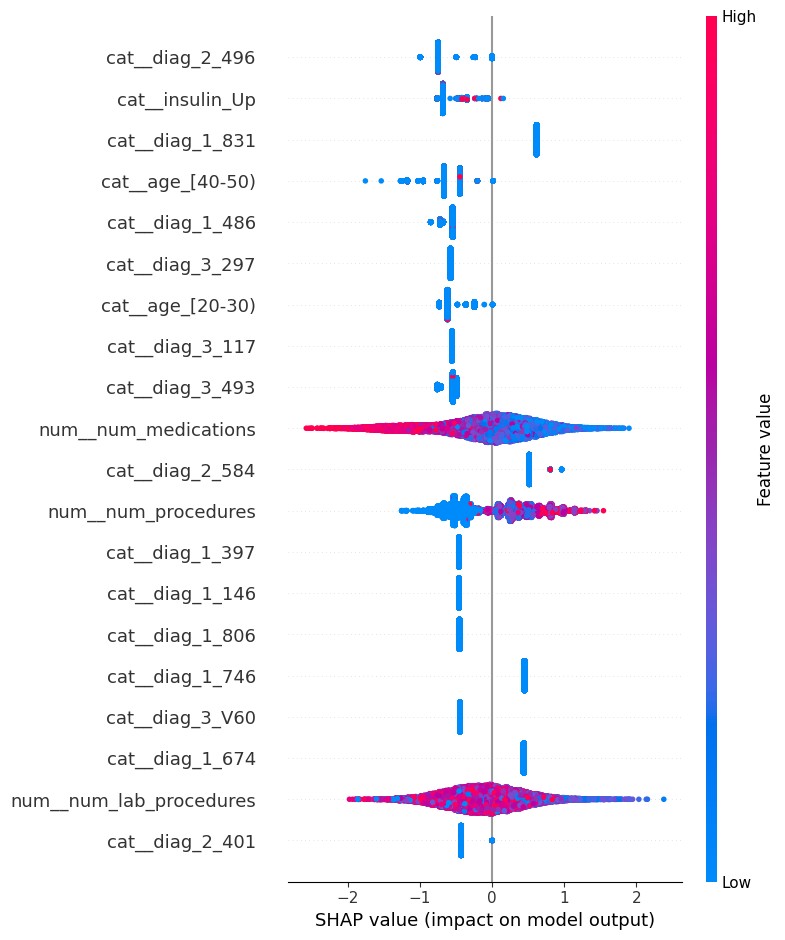

In [67]:
shap.summary_plot(shap_values_xgb[:,:,0], X_test_processed_xgb_dense, feature_names=preprocessor_xgb.get_feature_names_out())

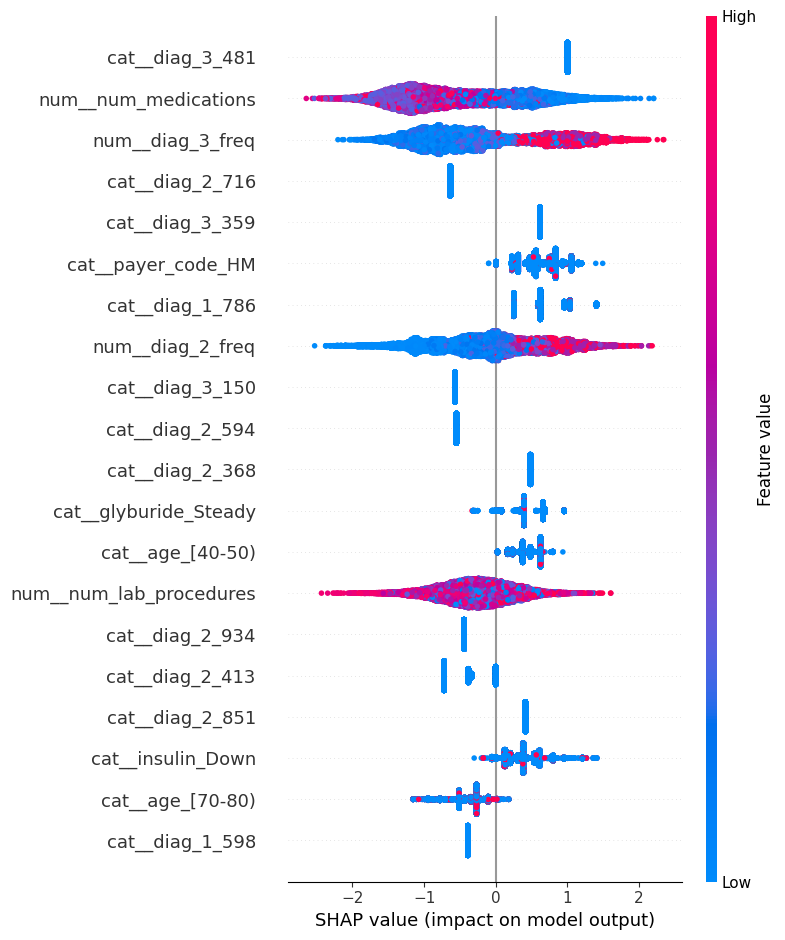

In [68]:
shap.summary_plot(shap_values_xgb[:,:,1], X_test_processed_xgb_dense, feature_names=preprocessor_xgb.get_feature_names_out())

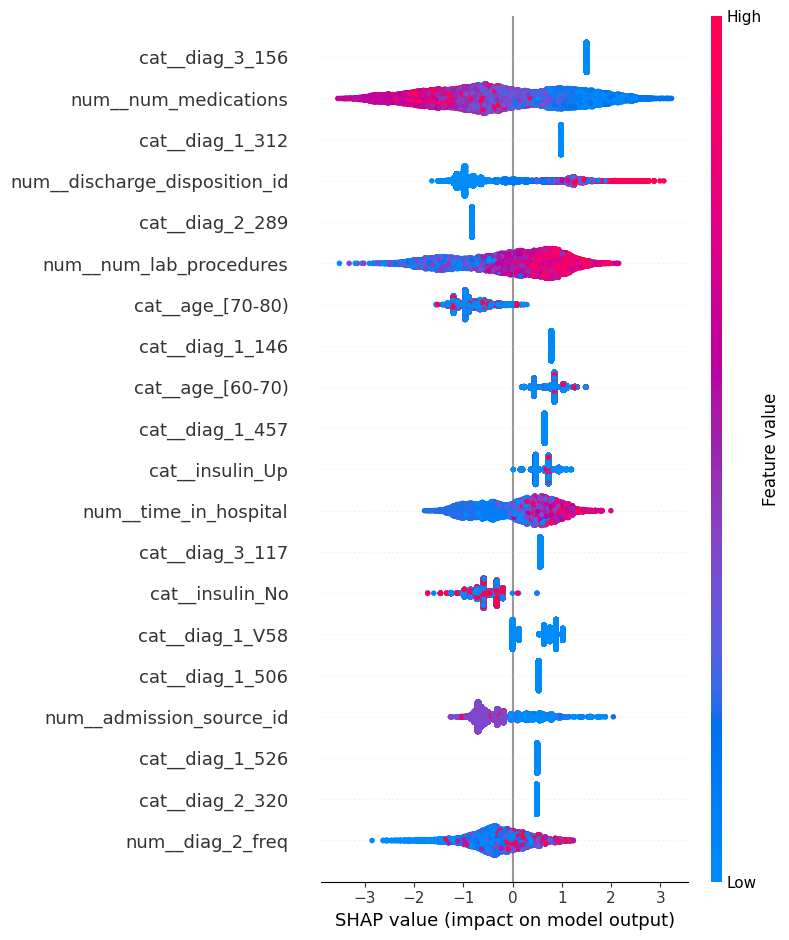

In [69]:
shap.summary_plot(shap_values_xgb[:,:,2], X_test_processed_xgb_dense, feature_names=preprocessor_xgb.get_feature_names_out())

### Ada

In [95]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

explainer = LimeTabularExplainer(
    training_data=X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=['No', '<30', '>30'],
    mode='classification'
)

In [107]:
i = 124
instance = X_test_processed[i]

predict_fn = lambda x: ada_pipeline.named_steps['classifier'].predict_proba(x)

exp = explainer.explain_instance(
    data_row=instance.toarray()[0] if hasattr(instance, "toarray") else instance,
    predict_fn=predict_fn,
    num_features=50,
)

exp.save_to_file('lime_explanation_1.html')

### Fairness

In [120]:
y_pred = rf_pipeline.predict(X_test)

sensitive_feature = X_test['gender']

frame = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'f1_macro': lambda y_true, y_pred: f1_score(y_true, y_pred, average='macro'),
        'selection_rate': selection_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_feature
)

print(frame.by_group)

dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_feature)
print(f"Demographic Parity Difference: {dpd:.3f}")

        accuracy  f1_macro  selection_rate
gender                                    
Female  0.577835  0.375823        0.230170
Male    0.590253  0.373394        0.201004
Demographic Parity Difference: 0.029


In [114]:
y_pred = rf_pipeline.predict(X_test)

sensitive_feature = X_test['race']
sensitive_feature = sensitive_feature.fillna('Unknown')

frame = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'f1_macro': lambda y_true, y_pred: f1_score(y_true, y_pred, average='macro'),
        'selection_rate': selection_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_feature
)

print(frame.by_group)

dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_feature)
print(f"Demographic Parity Difference: {dpd:.3f}")

                 accuracy  f1_macro  selection_rate
race                                               
AfricanAmerican  0.590572  0.372439        0.208951
Asian            0.653226  0.336926        0.104839
Caucasian        0.577404  0.375618        0.224128
Hispanic         0.608696  0.372350        0.190821
Other            0.611111  0.373093        0.215686
Unknown          0.676149  0.340693        0.076586
Demographic Parity Difference: 0.148


In [121]:
y_pred = ada_pipeline.predict(X_test)

sensitive_feature = X_test['gender']

frame = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'f1_macro': lambda y_true, y_pred: f1_score(y_true, y_pred, average='macro'),
        'selection_rate': selection_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_feature
)

print(frame.by_group)

dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_feature)
print(f"Demographic Parity Difference: {dpd:.3f}")

        accuracy  f1_macro  selection_rate
gender                                    
Female  0.577372  0.384209        0.250556
Male    0.590358  0.387799        0.236352
Demographic Parity Difference: 0.014


In [115]:
y_pred = ada_pipeline.predict(X_test)

sensitive_feature = X_test['race']
sensitive_feature = sensitive_feature.fillna('Unknown')

frame = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'f1_macro': lambda y_true, y_pred: f1_score(y_true, y_pred, average='macro'),
        'selection_rate': selection_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_feature
)

print(frame.by_group)

dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_feature)
print(f"Demographic Parity Difference: {dpd:.3f}")

                 accuracy  f1_macro  selection_rate
race                                               
AfricanAmerican  0.591102  0.393974        0.229608
Asian            0.661290  0.358396        0.145161
Caucasian        0.576815  0.383364        0.255875
Hispanic         0.615942  0.438426        0.200483
Other            0.611111  0.369707        0.202614
Unknown          0.673961  0.322538        0.054705
Demographic Parity Difference: 0.201


In [122]:
y_pred = xgb_pipeline.predict(X_test)

sensitive_feature = X_test['gender']

frame = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'f1_macro': lambda y_true, y_pred: f1_score(y_true, y_pred, average='macro'),
        'selection_rate': selection_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_feature
)

print(frame.by_group)

dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_feature)
print(f"Demographic Parity Difference: {dpd:.3f}")

        accuracy  f1_macro  selection_rate
gender                                    
Female  0.582191  0.422442        0.314400
Male    0.586802  0.417251        0.277139
Demographic Parity Difference: 0.037


In [116]:
y_pred = xgb_pipeline.predict(X_test)

sensitive_feature = X_test['race']
sensitive_feature = sensitive_feature.fillna('Unknown')

frame = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'f1_macro': lambda y_true, y_pred: f1_score(y_true, y_pred, average='macro'),
        'selection_rate': selection_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_feature
)

print(frame.by_group)

dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_feature)
print(f"Demographic Parity Difference: {dpd:.3f}")

                 accuracy  f1_macro  selection_rate
race                                               
AfricanAmerican  0.592691  0.424954        0.286811
Asian            0.645161  0.354566        0.161290
Caucasian        0.577142  0.417941        0.309158
Hispanic         0.620773  0.435542        0.195652
Other            0.601307  0.417212        0.248366
Unknown          0.695842  0.430523        0.131291
Demographic Parity Difference: 0.178


| Model   | Gender | Accuracy | F1 Macro | Selection Rate | Demographic Parity Difference |
| :------ | :----- | :------- | :------- | :------------- | :---------------------------- |
| **RF**  | Female | 0.5778   | 0.3758   | 0.2302         | **0.029**                     |
|         | Male   | 0.5903   | 0.3734   | 0.2010         |                               |
| **ADA** | Female | 0.5774   | 0.3842   | 0.2506         | **0.014**                     |
|         | Male   | 0.5904   | 0.3878   | 0.2364         |                               |
| **XGB** | Female | 0.5822   | 0.4224   | 0.3144         | **0.037**                     |
|         | Male   | 0.5868   | 0.4173   | 0.2771         |                               |


| Model   | Race            | Accuracy | F1 Macro | Selection Rate | Demographic Parity Difference |
| :------ | :-------------- | :------- | :------- | :------------- | :---------------------------- |
| **RF**  | AfricanAmerican | 0.5906   | 0.3724   | 0.2090         | **0.148**                     |
|         | Asian           | 0.6532   | 0.3369   | 0.1048         |                               |
|         | Caucasian       | 0.5774   | 0.3756   | 0.2241         |                               |
|         | Hispanic        | 0.6087   | 0.3724   | 0.1908         |                               |
|         | Other           | 0.6111   | 0.3731   | 0.2157         |                               |
|         | Unknown         | 0.6761   | 0.3407   | 0.0766         |                               |
| **ADA** | AfricanAmerican | 0.5911   | 0.3940   | 0.2296         | **0.201**                     |
|         | Asian           | 0.6613   | 0.3584   | 0.1452         |                               |
|         | Caucasian       | 0.5768   | 0.3834   | 0.2559         |                               |
|         | Hispanic        | 0.6159   | 0.4384   | 0.2005         |                               |
|         | Other           | 0.6111   | 0.3697   | 0.2026         |                               |
|         | Unknown         | 0.6740   | 0.3225   | 0.0547         |                               |
| **XGB** | AfricanAmerican | 0.5927   | 0.4250   | 0.2868         | **0.178**                     |
|         | Asian           | 0.6452   | 0.3546   | 0.1613         |                               |
|         | Caucasian       | 0.5771   | 0.4179   | 0.3092         |                               |
|         | Hispanic        | 0.6208   | 0.4355   | 0.1957         |                               |
|         | Other           | 0.6013   | 0.4172   | 0.2484         |                               |
|         | Unknown         | 0.6958   | 0.4305   | 0.1313         |                               |
